# `E_macro` — Source A and Source E: what the groups revealed

**Status report, 13 August 2026**, covering two weeks of work. Roughly 30 minutes;
sections 1–6 are the talk, the appendix is so the notebook stands on its own
afterwards.

The assignment was to split Sources A and E into groups and see whether they
should be modelled separately. The answer is **no, for both** — and the groups
were worth having anyway, because of what they exposed on the way to that answer.

The same question then turned out to generalise: if a pillar has to earn the right
to branch, it also has to earn its slot at all. Section 5 asks that of all six.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import json
import subprocess
import textwrap
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter

# Walk up to the repo root rather than assuming a directory name: this notebook
# is executed from analysis-output/ when it is the deliverable and from build/
# when it is staged for the HTML export, and both have to resolve the same way.
REPO = Path.cwd()
while not (REPO / "analysis-output").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
OUTPUTS, ANALYSIS = REPO / "outputs", REPO / "analysis-output"
XSRC = ANALYSIS / "cross-source"

# ---- artifacts -----------------------------------------------------------
ext = json.loads((XSRC / "external_target_stats.json").read_text())
blk = json.loads((XSRC / "pillar_block_marginal_stats.json").read_text())
gst = json.loads((XSRC / "grain_effect_stats.json").read_text())
scope = json.loads((ANALYSIS / "source-a" / "source_a_section_scope_stats.json").read_text())
embed = json.loads((ANALYSIS / "source-a" / "source_a_tiered_embedding_stats.json").read_text())
asec = json.loads((ANALYSIS / "source-a" / "source_a_section_stats.json").read_text())
atier = json.loads((ANALYSIS / "source-a" / "source_a_tier_stats.json").read_text())
arep = json.loads((ANALYSIS / "source-a" / "source_a_representation_stats.json").read_text())
etier = json.loads((ANALYSIS / "source-e" / "source_e_tier_stats.json").read_text())

A_TIERS = ["stub", "thin", "mid", "rich"]

placebo = pd.read_csv(OUTPUTS / "external_target_drop_one_placebo.csv")
decile = pd.read_csv(OUTPUTS / "external_target_by_decile.csv")
vintages = pd.read_csv(OUTPUTS / "pillar_vintages.csv")

PILLARS = ["A", "B", "C", "D", "E", "F"]
PILLAR_NAME = {
    "A": "A · Place identity",
    "B": "B · Industrial core",
    "C": "C · Economic velocity",
    "D": "D · Trade logistics",
    "E": "E · Capital flow",
    "F": "F · Structural resilience",
}
TARGET_LABEL = {
    "broadband_rate": "Broadband adoption",
    "median_household_income": "Median household income",
    "median_age": "Median age",
    "median_home_value": "Median home value",
    "mean_commute_minutes": "Mean commute",
}
TARGET_ORDER = list(TARGET_LABEL)

# ---- palette -------------------------------------------------------------
# Same validated reference palette as the brief this notebook replaces.
# Categorical slots are fixed, never cycled: a series keeps its slot when
# others are added or removed.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLUE, AQUA, CRITICAL = SERIES[0], SERIES[2], "#d03b3b"
SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID = "#d5d4d0", "#ecebe6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
})


def style(ax, title, subtitle="", grid_axis="y", legend=False):
    """House chart style, sized for a projector rather than a laptop.

    Matplotlib rather than plotly: plotly's mimetype output needs a JupyterLab
    extension to render, and silently produces blank space when that extension
    is missing. Matplotlib emits a PNG that every notebook client and the HTML
    export display without any additional machinery.

    Chrome is recessive — no spines, a hairline grid on one axis only, tick
    labels a step down from the body — so the bars carry the figure.
    """
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color=GRID, linewidth=1)
    ax.grid(axis="x" if grid_axis == "y" else "y", visible=False)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0, colors=INK2, labelsize=10.5)

    # Subtitles run long; wrapping by hand keeps them off the plot area, which
    # matplotlib will not do on its own. Both title and subtitle are positioned
    # in points offset from the axes edge rather than in axes fractions -- mixing
    # the two units makes them overlap, and by how much depends on figure height.
    sub = textwrap.fill(subtitle, 104) if subtitle else ""
    n_lines = sub.count("\n") + 1 if subtitle else 0
    line_h = 14.5
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", color=INK,
                 pad=(8 + n_lines * line_h + 8) if subtitle else 12)
    if subtitle:
        ax.annotate(sub, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 8), textcoords="offset points",
                    va="bottom", ha="left", fontsize=10, color=INK2,
                    linespacing=1.45)
    if legend:
        ax.legend(loc="upper left", bbox_to_anchor=(0, -0.13), ncol=2,
                  frameon=False, fontsize=10.5, labelcolor=INK2,
                  handlelength=1.4, columnspacing=1.8)
    return ax


def label_bars(ax, xs, ys, fmt="{:+.4f}", size=10.5, pad=0.012, horizontal=False):
    """Write each bar's value just past its end, outside the bar.

    `pad` is a fraction of the axis span, so labels sit the same visual distance
    from the bar regardless of the units on the axis.
    """
    lo, hi = (ax.get_xlim() if horizontal else ax.get_ylim())
    off = (hi - lo) * pad
    for x, y in zip(xs, ys):
        if horizontal:
            ax.text(y + (off if y >= 0 else -off), x, fmt.format(y),
                    va="center", ha="left" if y >= 0 else "right",
                    fontsize=size, color=INK)
        else:
            ax.text(x, y + (off if y >= 0 else -off), fmt.format(y),
                    ha="center", va="bottom" if y >= 0 else "top",
                    fontsize=size, color=INK)


# ---- provenance ----------------------------------------------------------
sha = subprocess.run(
    ["git", "-C", str(REPO), "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True,
).stdout.strip()
# Tracked modifications only, and notebooks excluded: this notebook lives under
# analysis-output/ and its own execution would otherwise register as drift in
# the artifacts it is reporting on.
dirty = subprocess.run(
    ["git", "-C", str(REPO), "status", "--porcelain", "--untracked-files=no",
     "--", "outputs", "analysis-output", ":(exclude)*.ipynb"],
    capture_output=True, text=True,
).stdout.strip()

print(f"Run stamp · {date.today():%d %B %Y} · commit {sha}")
print("Every figure below is computed from outputs/ and analysis-output/,")
print("regenerated from data/*.parquet by the six analysis scripts on 13 Aug 2026.")
print("Regenerated artifacts vs. committed: "
      f"{'IDENTICAL — no drift' if not dirty else 'DIFFER — see git diff'}")
print()
print(f"Evidence base · {ext['n_targets']} external targets · {ext['fold_strategy']} "
      f"· {blk['n_null_reps']} null reps · seed {ext['random_seed']}")

Run stamp · 18 August 2026 · commit d9a021a
Every figure below is computed from outputs/ and analysis-output/,
regenerated from data/*.parquet by the six analysis scripts on 13 Aug 2026.
Regenerated artifacts vs. committed: IDENTICAL — no drift

Evidence base · 5 external targets · GroupKFold on state_fips (spatially blocked) · 49 null reps · seed 42


---

## 1. The assignment

**The task, as set:** split Source A and Source E into groups and find out whether
each pillar should be modelled separately by group.

**Why it was a real question.** Both pillars are built from sources whose *quality
varies enormously across counties*. A Wikipedia article can be three sentences or
three pages; an IRS county file can cover 900 tax returns or 900,000. If a pillar
behaves differently enough at the two ends, one global model fitted across all
3,143 counties is the wrong shape, and the fix is to let the groups have their own
parameters.

**The answer, for both pillars: no.** Neither should branch. Sections 2 and 3 are
what the groups exposed; section 4 is why branching loses anyway.

**What the groups were worth regardless.** They picked the feature family Source A
now ships, showed where to go looking for it, corrected a Source E conclusion from
round 1 that was backwards, and forced a disclosure that now travels with the
pillar. The tiers were never going to be the deliverable — they were the
instrument.

---

## 2. Source A — four content tiers

Counties split on the length of their Wikipedia lead section: **stub** (<100
characters), **thin** (100–283), **mid** (284–461), **rich** (≥462).

**One piece of context first, because it is why Source A looks the way it does.**
Source A used to ship a 1,024-dimension `bge-m3` embedding of each county's lead
section. It was cut and replaced by 29 typed columns — named industries,
universities, ports, protected land — extracted with a fixed lexicon.

**Two encoders have now been tested against those columns, and both are ties.**
bge-m3 at 1,024 dimensions and 2.2GB: 11 of 28 targets, p = 0.52. `all-MiniLM-L6-v2`
at 384 dimensions and 90MB, reading the full article rather than the lead: 14 of
28 targets, p = 0.76, with the median favouring the typed columns. Neither
encoder is beaten and neither wins.

**So the typed block ships on cost and interpretability, not on measured lift** —
and it is worth saying that plainly rather than implying the columns scored
better. What they buy is no model download, no inference, and a column you can
read the name of.

**What the tiers then contributed was the answer to "so what do we build
instead?"** The split showed where economic content actually lives in the corpus.

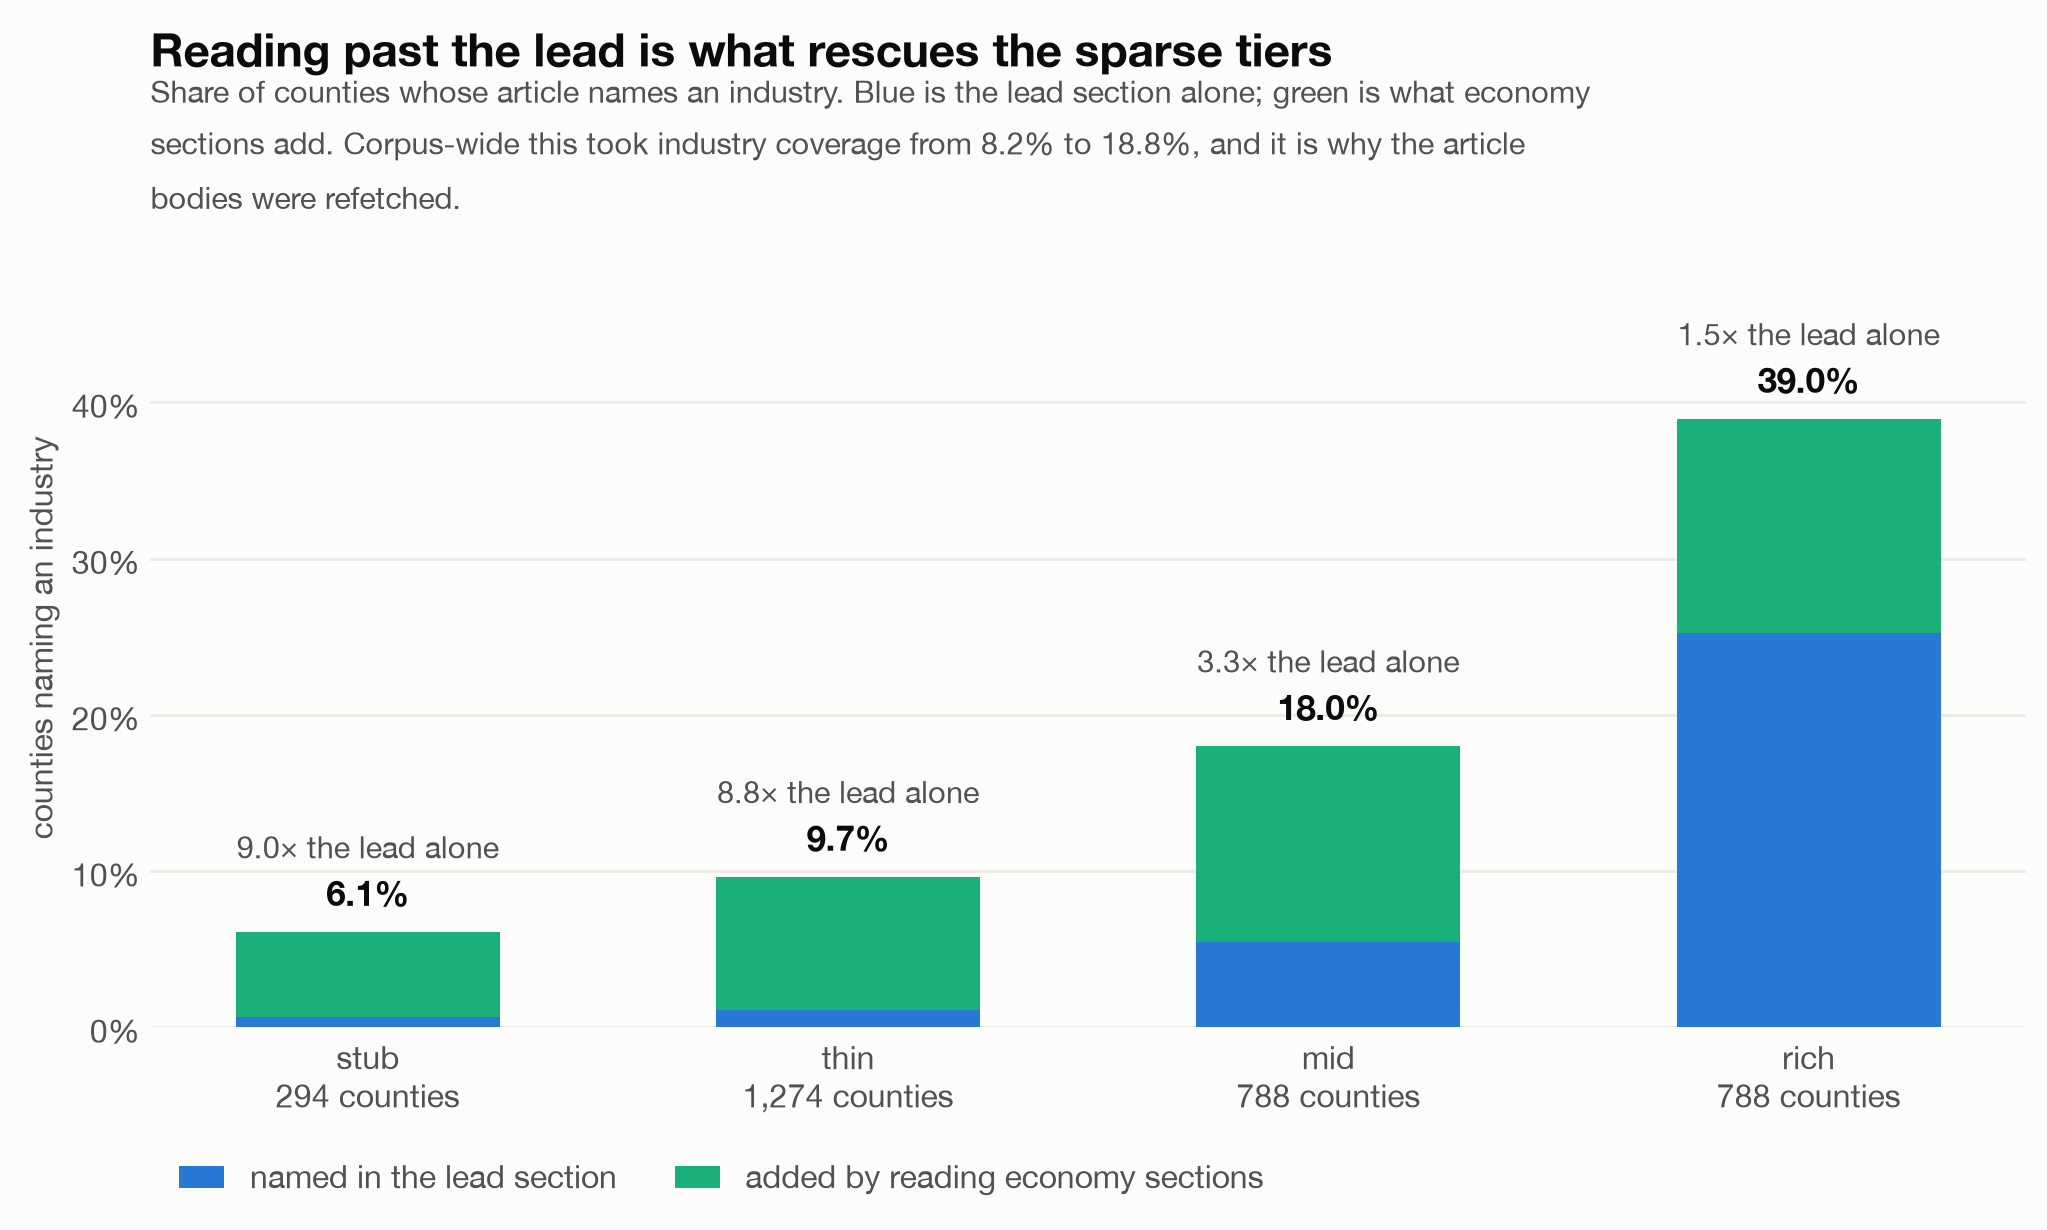

In [2]:
tiers = [t for t in A_TIERS if t in asec["by_tier"]]
lead = [asec["by_tier"][t]["share_intro_industry"] for t in tiers]
# `share_section_industry` OVERLAPS the lead measure — a county can name an
# industry in both places — so it is NOT an "after" value, and charting the two
# side by side implies a before/after that does not exist. `share_industry_added`
# is the genuine increment (section_has & ~intro_has), so lead + added is the
# union: the share of counties covered once economy sections are read as well.
added = [asec["by_tier"][t]["share_industry_added"] for t in tiers]
total = [l + a for l, a in zip(lead, added)]
n_by_tier = [asec["by_tier"][t]["n_counties"] for t in tiers]

x = np.arange(len(tiers))
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(x, lead, 0.55, color=BLUE, label="named in the lead section")
ax.bar(x, added, 0.55, bottom=lead, color=AQUA,
       label="added by reading economy sections")
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n{n:,} counties" for t, n in zip(tiers, n_by_tier)])
ax.set_ylim(0, max(total) * 1.28)

# Total above each bar, and the multiple it represents -- the multiple is the
# point of the figure, so it is stated rather than left to be eyeballed.
for xi, l, t in zip(x, lead, total):
    ax.text(xi, t + max(total) * 0.03, f"{t:.1%}", ha="center", va="bottom",
            fontsize=11.5, fontweight="bold", color=INK)
    # One decimal: every multiple here is under 10, and rounding 1.54 to "2×"
    # overstates the rich tier's gain in the direction the section argues.
    ax.text(xi, t + max(total) * 0.11, f"{t / l:.1f}× the lead alone", ha="center",
            va="bottom", fontsize=10, color=INK2)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("counties naming an industry", fontsize=10.5, color=INK2)
style(ax,
      "Reading past the lead is what rescues the sparse tiers",
      "Share of counties whose article names an industry. Blue is the lead section "
      "alone; green is what economy sections add. Corpus-wide this took industry "
      "coverage from 8.2% to 18.8%, and it is why the article bodies were refetched.",
      legend=True)
plt.show()

**Two decisions came out of this chart, and neither is the embedding one.**

**It picked the feature family.** The gradient in the blue bars — 0.7% of stub
articles naming an industry against 25.3% of rich — is what identified *industry*
as the thing worth extracting at all. The 29 typed columns Source A ships are built
around that choice.

**It showed where to find more of it, and that the fix was uniform.** The green
segments are what reading economy-titled sections adds. They help the sparse tiers
most — stub goes from 0.7% to **6.1%**, thin from 1.1% to **9.7%**, against rich's
25.3% to 39.0%. So the thin tiers are not empty pages; they are pages whose
economic content sits below the lead. **Reading *more* for everyone beat reading
*differently* by tier** — the first hint of the answer section 4 gives.

The chart is a diagnosis of the corpus, not a verdict on the embedding. It explains
why a lead-text vector would be information-poor; the measurements above are what
actually retired it.

**Then branching lost on its own terms, and the loss scaled with how much branching
there was.** Three ways to fit the *same* 29 columns, from most shared to least.
The difference between them is entirely in how many separate copies of a
coefficient the model is allowed to estimate, and how much data each copy sees:

- **One model, one coefficient per feature — 29 coefficients, fit once, on all
  3,143 counties.** `has_port` gets a single weight, and it applies whether the
  county is stub or rich. A stub county and a rich county are just two rows in
  the same regression. This is what ships.
- **One model, coefficients free to vary by tier — 120 coefficients (29 features
  × 4 tiers), fit once, still on all 3,143 counties.** Each county's 29 features
  are copied into the column slot for its own tier and zeroed out in the other
  three tiers' slots, plus a tier dummy so the intercept can shift too. So
  `has_port` is now four separate coefficients — `has_port_stub`, `has_port_thin`,
  `has_port_mid`, `has_port_rich` — each seeing only the rows from its own tier,
  because the other three copies are zero on that row. But it is still **one
  training run and one shared ridge penalty**: the penalty strength is chosen
  once, across all 3,143 rows, so a tier with nothing to say still gets shrunk by
  a penalty the other three tiers helped pick.
- **Four models, one fitted per tier — 29 coefficients × 4, but four separate
  training runs, each on only its own tier's counties.** The shared fit is
  abandoned entirely: stub's model never sees a thin, mid, or rich row, and each
  tier picks its own ridge penalty from its own data alone. Nothing is borrowed
  across tiers — not the coefficients, not the penalty, not the sample.

The three arms are ordered by how much sharing survives: full sharing (one
coefficient set, one sample, one penalty) → shared sample and penalty but split
coefficients → nothing shared at all.

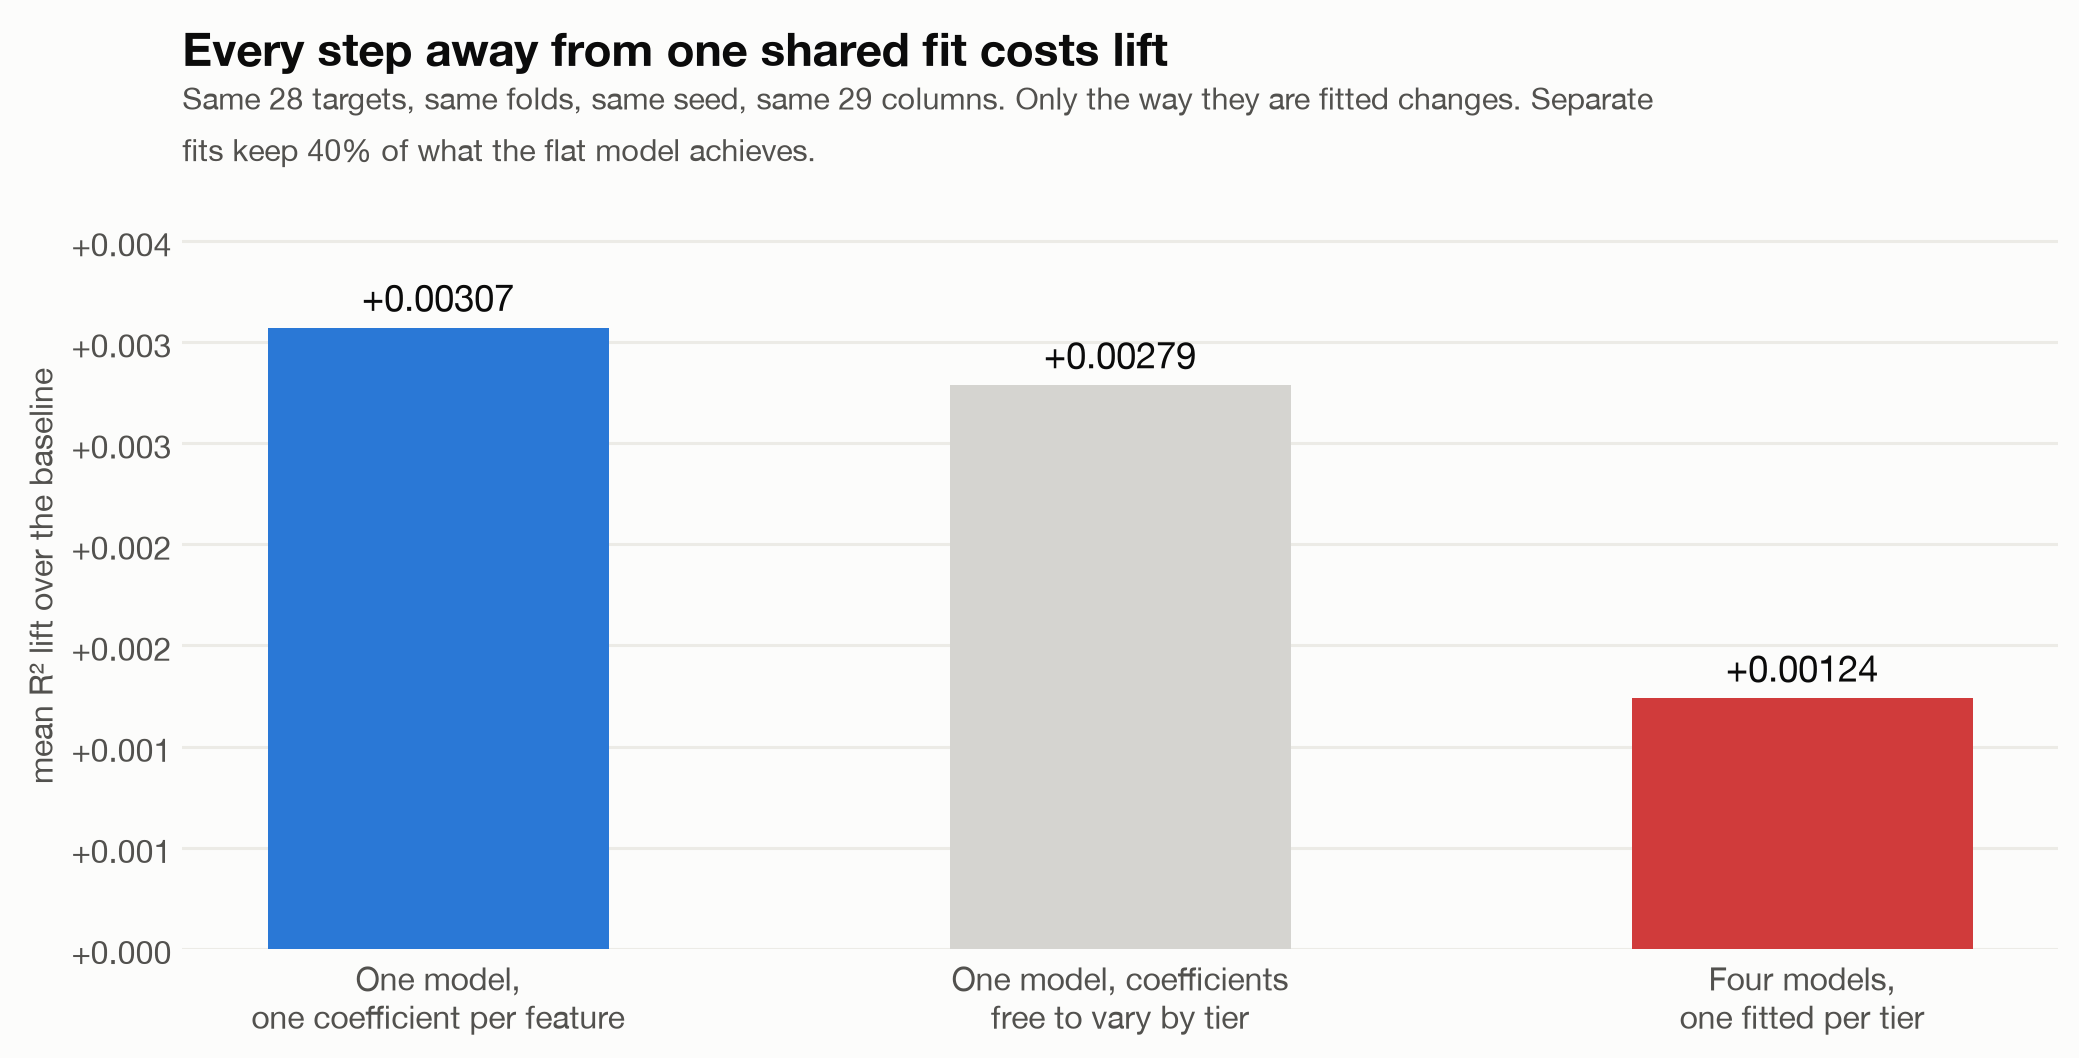

In [3]:
ARMS = [
    ("One model,\none coefficient per feature", "extracted_sections", BLUE),
    ("One model, coefficients\nfree to vary by tier", "sections_x_tier", MUTED),
    ("Four models,\none fitted per tier", "sections_per_tier", CRITICAL),
]
x = np.arange(len(ARMS))
vals = [arep["variants"][k]["mean_lift"] for _, k, _ in ARMS]

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.bar(x, vals, 0.5, color=[c for _, _, c in ARMS])
ax.set_xticks(x)
ax.set_xticklabels([a for a, _, _ in ARMS])
ax.set_ylim(0, max(vals) * 1.2)
label_bars(ax, x, vals, "{:+.5f}", size=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
ax.set_ylabel("mean R² lift over the baseline", fontsize=10.5, color=INK2)
style(ax,
      "Every step away from one shared fit costs lift",
      f"Same 28 targets, same folds, same seed, same 29 columns. Only the way they "
      f"are fitted changes. Separate fits keep "
      f"{vals[2] / vals[0]:.0%} of what the flat model achieves.")
plt.show()

Letting coefficients vary by tier costs **9%** of the lift. Fitting four separate
models costs **60%** — it is still positive, but it gives back most of what the
section refetch bought, landing barely above the single `content_length` scalar
Source A used to ship.

**And the aggregate hides something more interesting.** Branching did not fail
everywhere. It failed on balance.

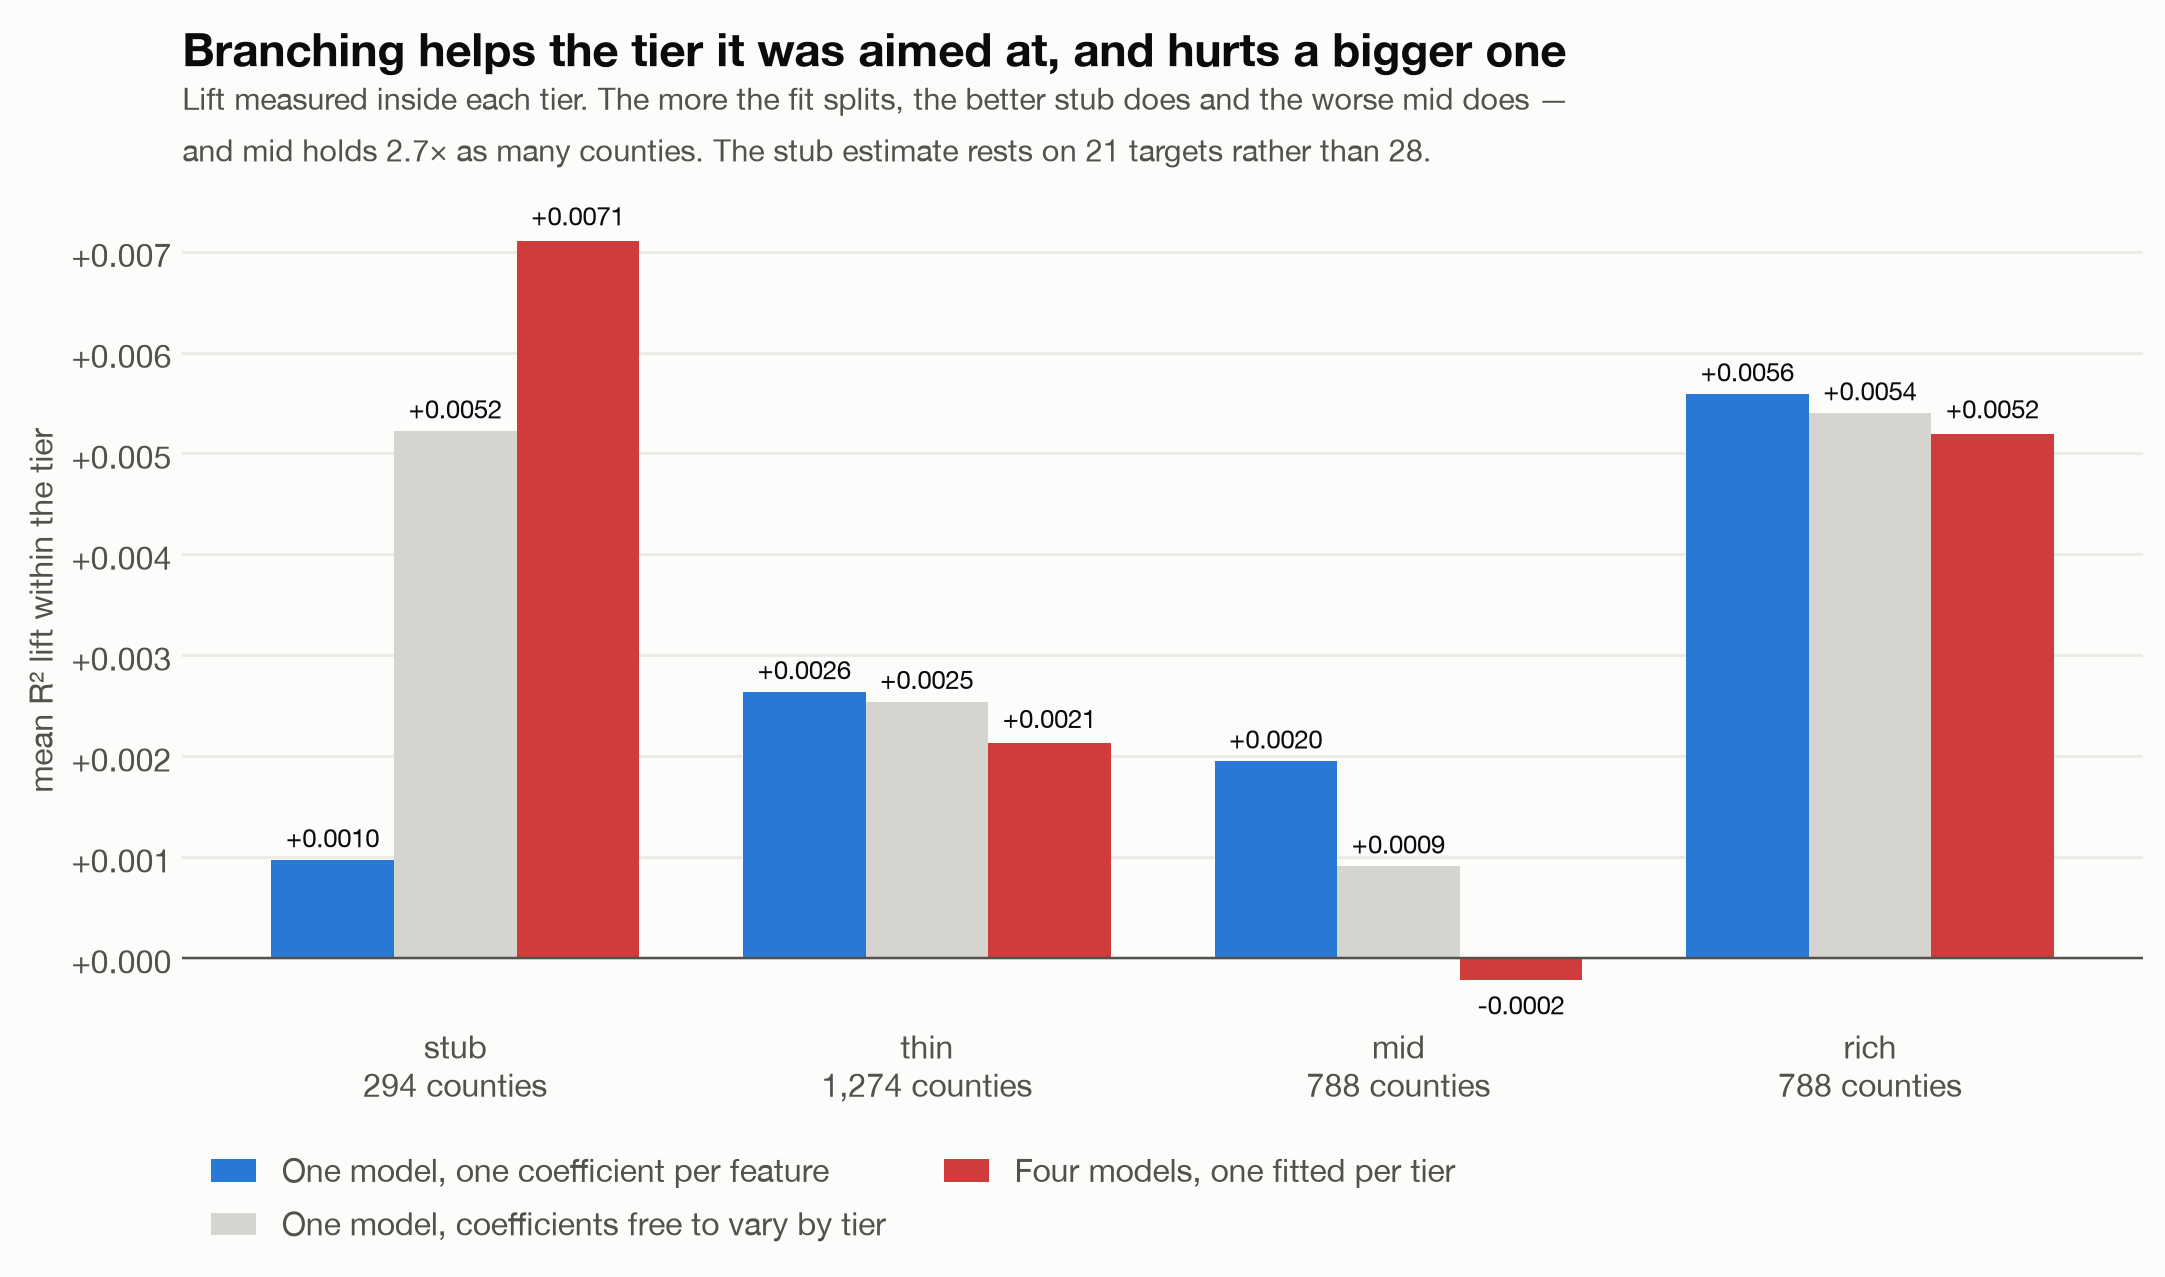

In [4]:
by_tier = pd.read_csv(OUTPUTS / "source_a_representation_by_tier.csv")
keys = [k for _, k, _ in ARMS]
per_tier = (by_tier[by_tier["variant"].isin(keys)]
            .groupby(["variant", "tier"])["lift"].mean().unstack())
tiers = [t for t in A_TIERS if t in per_tier.columns]
n_by_tier = [asec["by_tier"][t]["n_counties"] for t in tiers]

x = np.arange(len(tiers))
w = 0.26
fig, ax = plt.subplots(figsize=(11.5, 4.8))
for i, (label, key, colour) in enumerate(ARMS):
    vals = [per_tier.loc[key, t] for t in tiers]
    ax.bar(x + (i - 1) * w, vals, w, color=colour,
           label=label.replace("\n", " "))
    label_bars(ax, x + (i - 1) * w, vals, "{:+.4f}", size=8.5)
ax.axhline(0, color=INK2, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n{n:,} counties" for t, n in zip(tiers, n_by_tier)])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
ax.set_ylabel("mean R² lift within the tier", fontsize=10.5, color=INK2)
style(ax,
      "Branching helps the tier it was aimed at, and hurts a bigger one",
      "Lift measured inside each tier. The more the fit splits, the better stub "
      "does and the worse mid does — and mid holds 2.7× as many counties. The stub "
      "estimate rests on 21 targets rather than 28.",
      legend=True)
plt.show()

**So the instinct was right and the arithmetic was not.** Branching helps the
tier it was aimed at — the sparser articles are exactly where more flexible
fitting pays off. But mid moves the opposite way at every step, and mid holds
2.7× as many counties as stub. The weighted result follows the bigger tier, not
the one branching was built for.

**The mechanism is ordinary bias–variance.** Crossing 29 features with 4 tiers
puts **120 columns** against targets whose smallest sample is n ≈ 1,026. The
ridge penalty large enough to control that width also **over-shrinks the
coefficients that were doing the work in the flat model** — so the crossed arm
pays for its extra expressiveness everywhere in order to help one tier. Fitting
four separate models removes even the shared penalty's protection, which is why
that arm goes properly negative rather than merely slightly worse.

The negative result is kept reproducible rather than left as folklore:
`sections_x_tier` is retained as a scored variant in
`analyze_source_a_representation.py`, so anyone can re-run it.

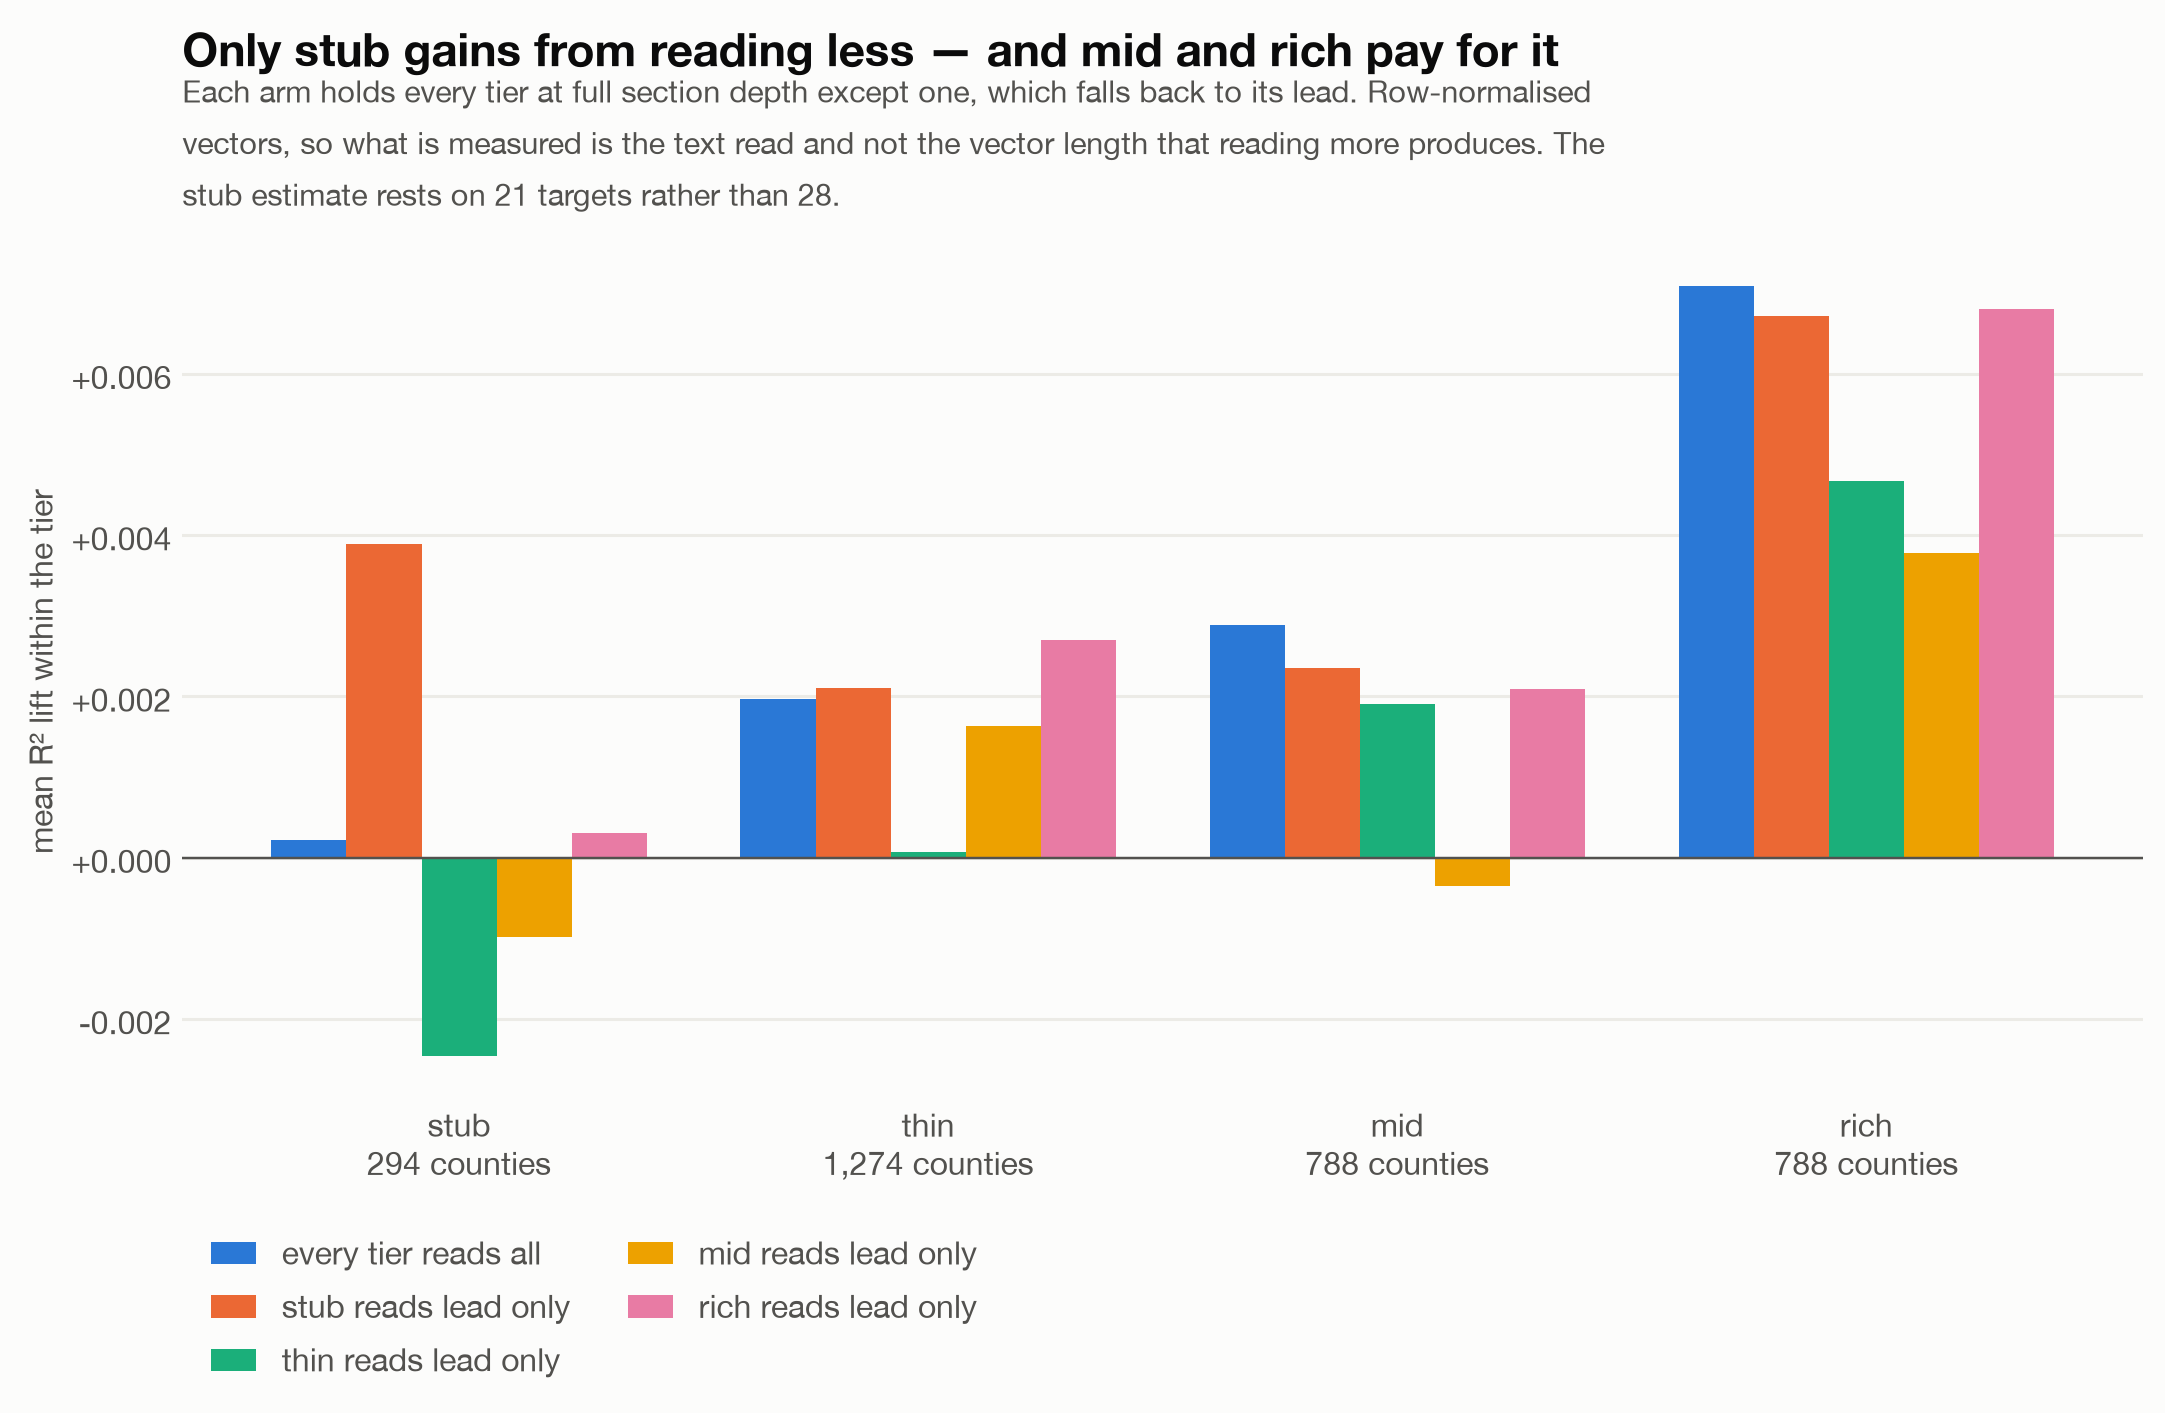

In [5]:
emb_tier = pd.read_csv(OUTPUTS / "source_a_tiered_embedding_by_tier.csv")
SWEEP = [
    ("uniform_l2", "every tier reads all", SERIES[0]),
    ("drop_stub_l2", "stub reads lead only", SERIES[1]),
    ("drop_thin_l2", "thin reads lead only", SERIES[2]),
    ("drop_mid_l2", "mid reads lead only", SERIES[3]),
    ("drop_rich_l2", "rich reads lead only", SERIES[4]),
]
piv = (emb_tier[emb_tier["representation"].isin([k for k, _, _ in SWEEP])]
       .groupby(["representation", "tier"])["lift"].mean().unstack())
tiers = [t for t in A_TIERS if t in piv.columns]
n_by_tier = [asec["by_tier"][t]["n_counties"] for t in tiers]

x = np.arange(len(tiers))
w = 0.16
fig, ax = plt.subplots(figsize=(11.5, 5.0))
for i, (key, label, colour) in enumerate(SWEEP):
    vals = [piv.loc[key, t] for t in tiers]
    ax.bar(x + (i - 2) * w, vals, w, color=colour, label=label)
ax.axhline(0, color=INK2, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n{n:,} counties" for t, n in zip(tiers, n_by_tier)])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
ax.set_ylabel("mean R² lift within the tier", fontsize=10.5, color=INK2)
style(ax,
      "Only stub gains from reading less — and mid and rich pay for it",
      "Each arm holds every tier at full section depth except one, which falls "
      "back to its lead. Row-normalised vectors, so what is measured is the text "
      "read and not the vector length that reading more produces. The stub "
      "estimate rests on 21 targets rather than 28.",
      legend=True)
plt.show()

**The encoder side of the same question, and the sign is not what the plan
expected.** Section 2 has so far asked whether the 29 typed columns should branch
on tier. This chart asks it of the input text itself: does it help to let each
tier's *article* stay uniform except one tier, which reads only its lead? Mean L2
lift within each tier, drop-one against `uniform`:

|            | stub     | thin     | mid      | rich     |
|------------|----------|----------|----------|----------|
| `uniform`  | +0.00021 | +0.00196 | +0.00288 | +0.00708 |
| drop stub  | +0.00388 | +0.00211 | +0.00235 | +0.00671 |
| drop thin  | −0.00247 | +0.00006 | +0.00191 | +0.00468 |
| drop mid   | −0.00098 | +0.00163 | −0.00035 | +0.00378 |
| drop rich  | +0.00030 | +0.00270 | +0.00210 | +0.00680 |

**Stub is predicted *better* when it stops reading its own article.** Withholding
stub's body text and falling back to its lead raises stub's own lift from
+0.00021 to +0.00388 — a diagonal gain of **+0.00367**. Stub's body text is not
neutral, it is actively counterproductive, which lines up with the corpus
diagnosis three charts back: a stub lead names an industry in 0.7% of counties, so
there is next to nothing in a stub article for the encoder to lose by not reading
past it.

**thin and mid are the tiers actually carrying signal.** Dropping thin's text
costs its own tier **−0.00190** (+0.00196 → +0.00006) and dropping mid's costs
**−0.00323** (+0.00288 → −0.00035) — both go from clearly positive to flat or
negative. rich barely moves, **−0.00028** (+0.00708 → +0.00680): the tier with the
most text to read is close to redundant over its own lead.

**And `uniform` still wins pooled, for the same structural reason section 2
already gave the typed columns.** Stub's own-tier gain from dropping its text is
real, but `drop_stub` also costs mid (+0.00288 → +0.00235) and rich (+0.00708 →
+0.00671) through the one fit those four tiers share, and pooled it still loses to
`uniform`: **+0.00343** against **+0.00351**. That is cross-tier interference
through the shared model — a rule tuned to help one tier is paid for by the
others, exactly the mechanism behind the typed-column result above. The
off-diagonal cost is not always smaller than the diagonal gain, either:
`drop_thin` gives its own tier +0.00006 but costs the stub tier **−0.00247**, a
larger move in the opposite direction.

**The chart plots the row-normalised arm, and the gap to the raw arm is the
reason.** `tier_variance_share` — how much of the embedding's variance tracks
which tier a county is in, rather than anything else — sits at 0.0121 for
`uniform` and rises to 0.0481–0.0698 for the drop arms. Splicing a lead-only row
into an otherwise uniform arm manufactures a norm discontinuity at the tier
boundary: `lead_only` rows carry a norm of roughly 1.0 against `uniform`'s
0.63–0.71, so an unnormalised drop arm partly encodes *which tier a county is in*
through vector length rather than through content. Quoting one arm's raw-vs-L2
gap makes the size of that artifact concrete: `drop_stub` reads +0.00256 raw
against +0.00343 row-normalised, a 0.00087 gap.

**One line on how the drop arms are built, because it matters for what the
comparison is holding fixed.** Each `drop_*` arm is built by splicing that tier's
`lead_only` rows into the `uniform` arm's vectors, not by re-encoding the whole
corpus with a different reading rule. That is the cleaner contrast, not a
shortcut: the three untouched tiers in each arm are exactly `uniform`'s own
vectors, whereas re-encoding them would perturb each by roughly 1e-7 of padding
noise — drift injected into precisely the tiers the comparison is supposed to
hold fixed.

**What this does not change.** `uniform` already beat every branching rule tested
on the typed columns, and it beats this one too. The typed block still ships on
cost and interpretability rather than on measured lift — this sweep sharpens *why*
branching loses on the encoder side, it does not reopen what ships.

---

## 3. Source E — four volume tiers

Counties split on `num_returns`: **T1** (<2,200), **T2** (2,200–11,700), **T3**
(11,700–100,000), **T4** (≥100,000).

Here the split did something more uncomfortable than guide a feature choice. It
showed that **the pillar and the economy it claims to describe are not the same
object.**

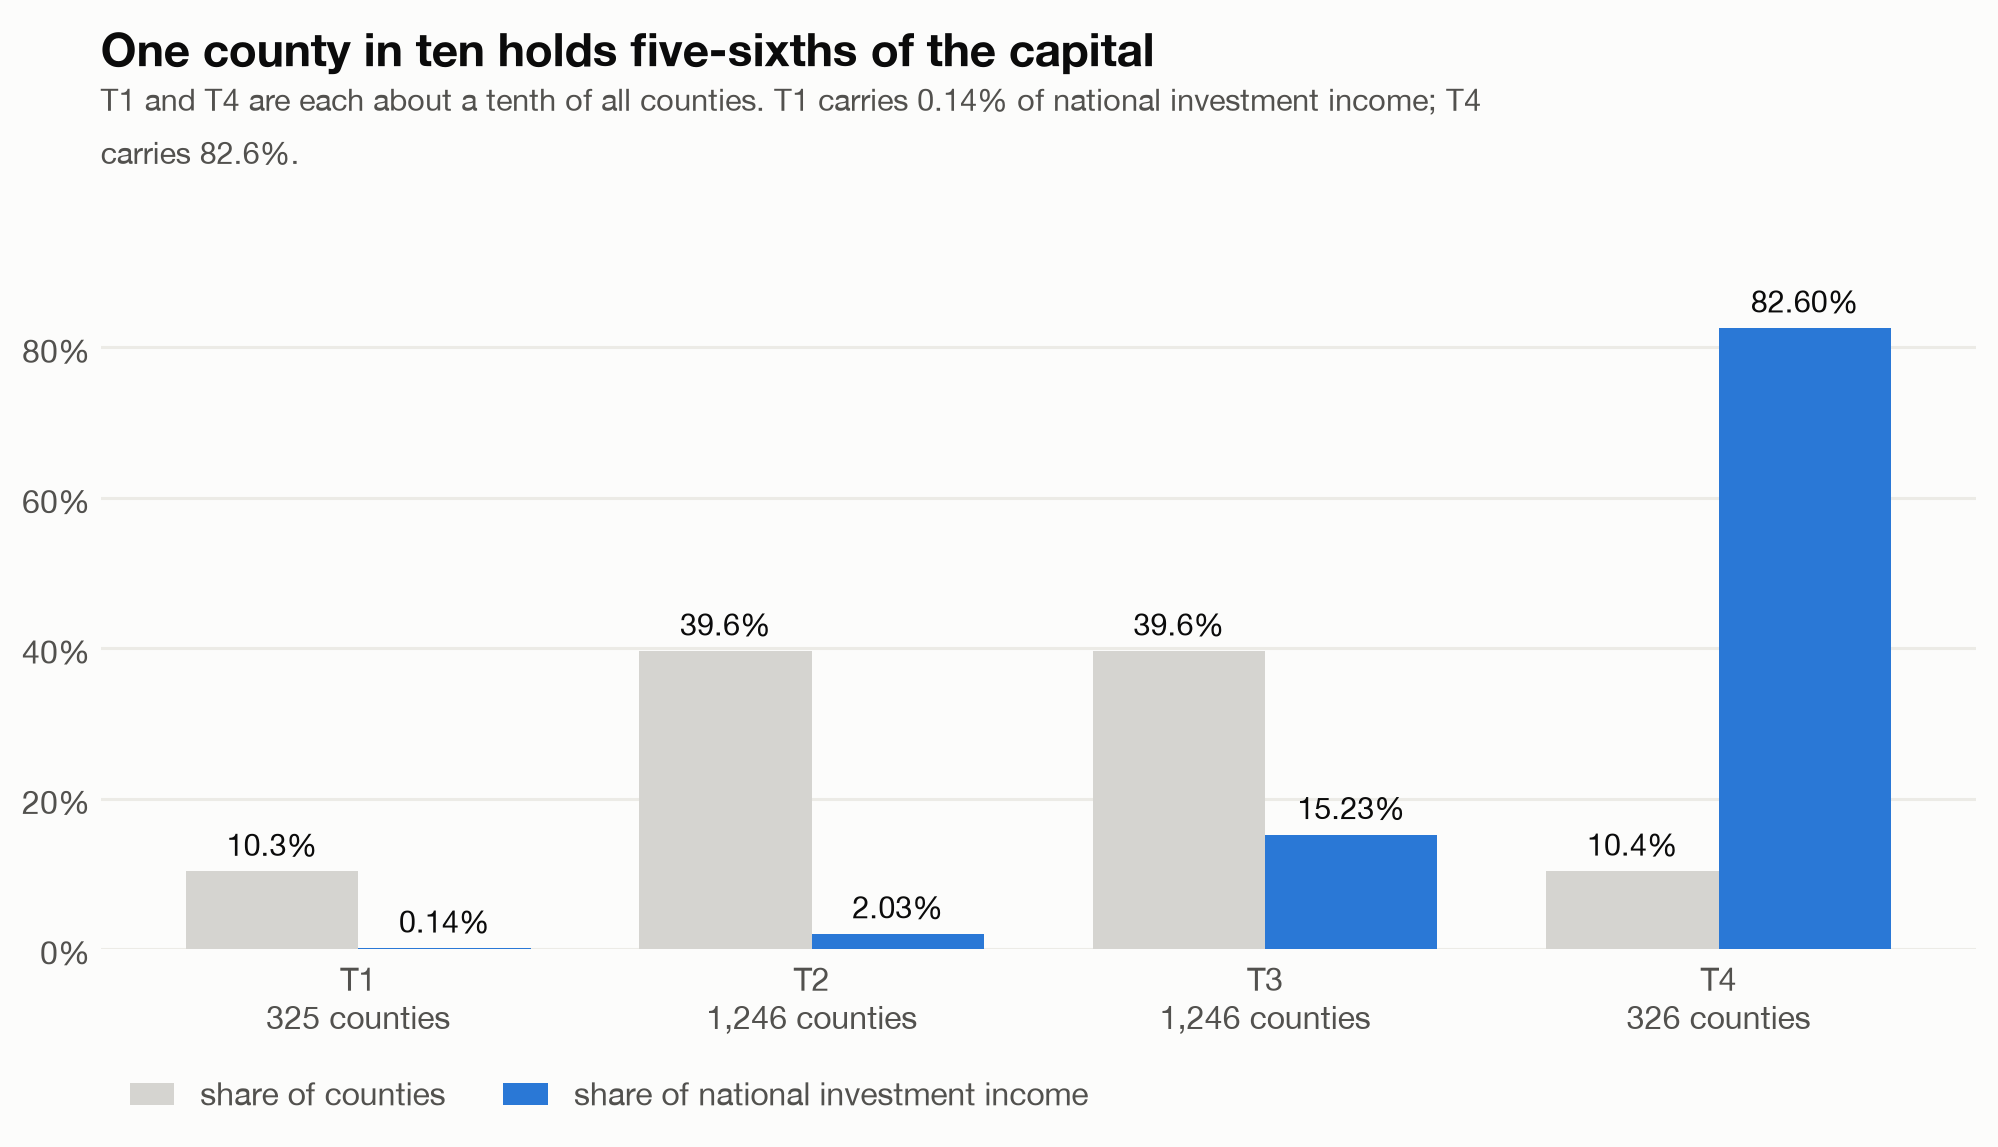

In [6]:
tiers = list(etier["tiers"].keys())
short = [t.split()[0] for t in tiers]
cty = [etier["tiers"][t]["share_of_counties"] for t in tiers]
inv = [etier["tiers"][t]["share_of_investment_income"] for t in tiers]

x = np.arange(len(tiers))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.bar(x - w / 2, cty, w, color=MUTED, label="share of counties")
ax.bar(x + w / 2, inv, w, color=BLUE, label="share of national investment income")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n{etier['tiers'][t]['n_counties']:,} counties"
                    for s, t in zip(short, tiers)])
ax.set_ylim(0, max(cty + inv) * 1.2)
label_bars(ax, x - w / 2, cty, "{:.1%}", size=10)
label_bars(ax, x + w / 2, inv, "{:.2%}", size=10)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
style(ax,
      "One county in ten holds five-sixths of the capital",
      f"T1 and T4 are each about a tenth of all counties. T1 carries "
      f"{inv[0]:.2%} of national investment income; T4 carries {inv[-1]:.1%}.",
      legend=True)
plt.show()

**Why that matters beyond the chart.** An unweighted county-level capital feature
treats a T1 county and a T4 county as equal observations, when one of them holds
essentially none of the thing being measured. That is not a reason to weight the
feature — weighting was tested and rejected below — but it is a reason to *say so*,
which Source E's schema doc now does.

**Two corrections the split forced, both against earlier conclusions of mine:**

- **Round 1 had the stability backwards.** I had said small counties were the
  volatile ones. On ranks it is the opposite: Spearman stability *improves* with
  size (0.861 → 0.941) and median year-over-year moves *rise* with size
  (0.298 → 0.393). Round 1's proposed fix — weighting by `num_returns` — would have
  upweighted exactly the counties whose values move most between vintages.
- **The dispersion is not thin-data noise.** Regressing log dispersion on log
  median returns gives a slope of **+0.026**, where pure sampling error would give
  −0.5. Small counties' spread is real economic variation, so there is nothing to
  smooth away.

**And one caveat that now ships with the pillar.** The strongest cross-pillar link
in the whole project — Source B real-estate location quotient against Source E
capital-to-wage — is a large-county phenomenon: **+0.476 in T4 against −0.058 in
T1**. Anyone serving rural inventory needs that said out loud before leaning on it.

---

## 4. Why neither pillar branches

The two pillars fail branching for the same underlying reason, and it is
measurable rather than rhetorical.

**Partitioning 3,143 counties costs more in pooled evidence than heterogeneity
costs in bias.** Each per-tier model trains on a fraction of the rows; the variance
that buys is larger than the bias it removes.

**The construction rule leaks into the representation.** Where the tiers were used
conditionally, tier membership alone explains **3.7–6.6%** of the vector's variance,
against **0.9–1.0%** under a uniform rule — four to seven times more, for a variable
the baseline already controls for. The model was partly learning how the input was
built rather than anything about the counties.

**And the same answer comes back from an independent test.** Section 2 branched the
*model* on tier. The encoder experiment branched the *input* — deciding how much of
each article to read based on its tier — on different machinery entirely. Reading
the same text for everyone wins there too: **+0.00322 uniform against +0.00180
tier-conditional and +0.00068 for the inverted rule.** Two tests, two layers, one
conclusion.

**So what shipped instead:**

- **Source A ships one uniform schema** — 29 typed columns, same for every county,
  absence encoded as `False`/`0` rather than null. Sparsity is itself the signal: a
  county whose article says nothing is a county about which little is written.
- **Source E ships with an explicit size-conditionality warning**, and prefers the
  vintage-normalised ratio over the raw one.

The groups changed **what gets shipped and what gets disclosed**. They did not
become part of the model, and that was the right outcome rather than a null one.

---

## 5. The same question, asked of all six

If a pillar has to earn the right to branch, it has to earn its slot at all. That
generalisation is what the second week tested.

**Every validation before it was pillar against pillar** — predict one federal
source's features from the other five. That measures whether six agencies agree
with each other; it cannot say whether any of them is *useful*. The bias even runs
the wrong way, penalising a source precisely for agreeing with the others. And a
real label is not available: the project is scoped to public data only, which is a
boundary, not an oversight.

**The substitute is five public outcomes no pillar measures** — ACS broadband
adoption, median household income, median age, median home value, mean commute.
None is constructed from any pillar's inputs.

**The design is built around one specific objection.** The consuming team joins on
DMA with millions of impressions per market, so it can estimate a geographic fixed
effect essentially for free — which makes any static geo-keyed feature look
redundant. A fixed effect has exactly one weakness: **no parameter for a place it
has never seen.** So the test holds out **whole states** and compares against a
model that knows only county size. That seam is the whole design, and it is what
section 4 returns to.

**The same seam then goes one level down.** Withhold a single pillar's block from a
model that already holds county size *and the other five*, and measure the R² it
loses. Three decisions make the result survivable: every pillar takes the same test;
restatements are ablated, so no pillar is paid for repeating a neighbour; and the
noise floor is measured by shuffling each block rather than assumed.

The pass/fail rule was written down before the numbers arrived and was not
renegotiated afterwards — full text in appendix A2.

### First, the discount applied to the result

The raw number is **+0.212**; the number reported is **+0.190**. Two pillar columns
don't so much predict their target as restate it. `wage_per_return_thousands` (IRS)
is average wage income per tax return, very close to a definition of median
household income — removing it drops that outcome's gain from +0.247 to **+0.154**,
so one column was carrying **38%** of the apparent result. `retirement_destination`
(USDA) restates age structure, at a smaller +0.256 → +0.239. Both are dropped from
their own target's run and kept everywhere else. **The headline is the discounted
number.**

**And within that result, what each pillar is worth.** Read the figure as: how much
predictive power the matrix loses when this pillar is taken out of it. The grey
band is the noise floor — the most any *shuffled* version of a block managed.

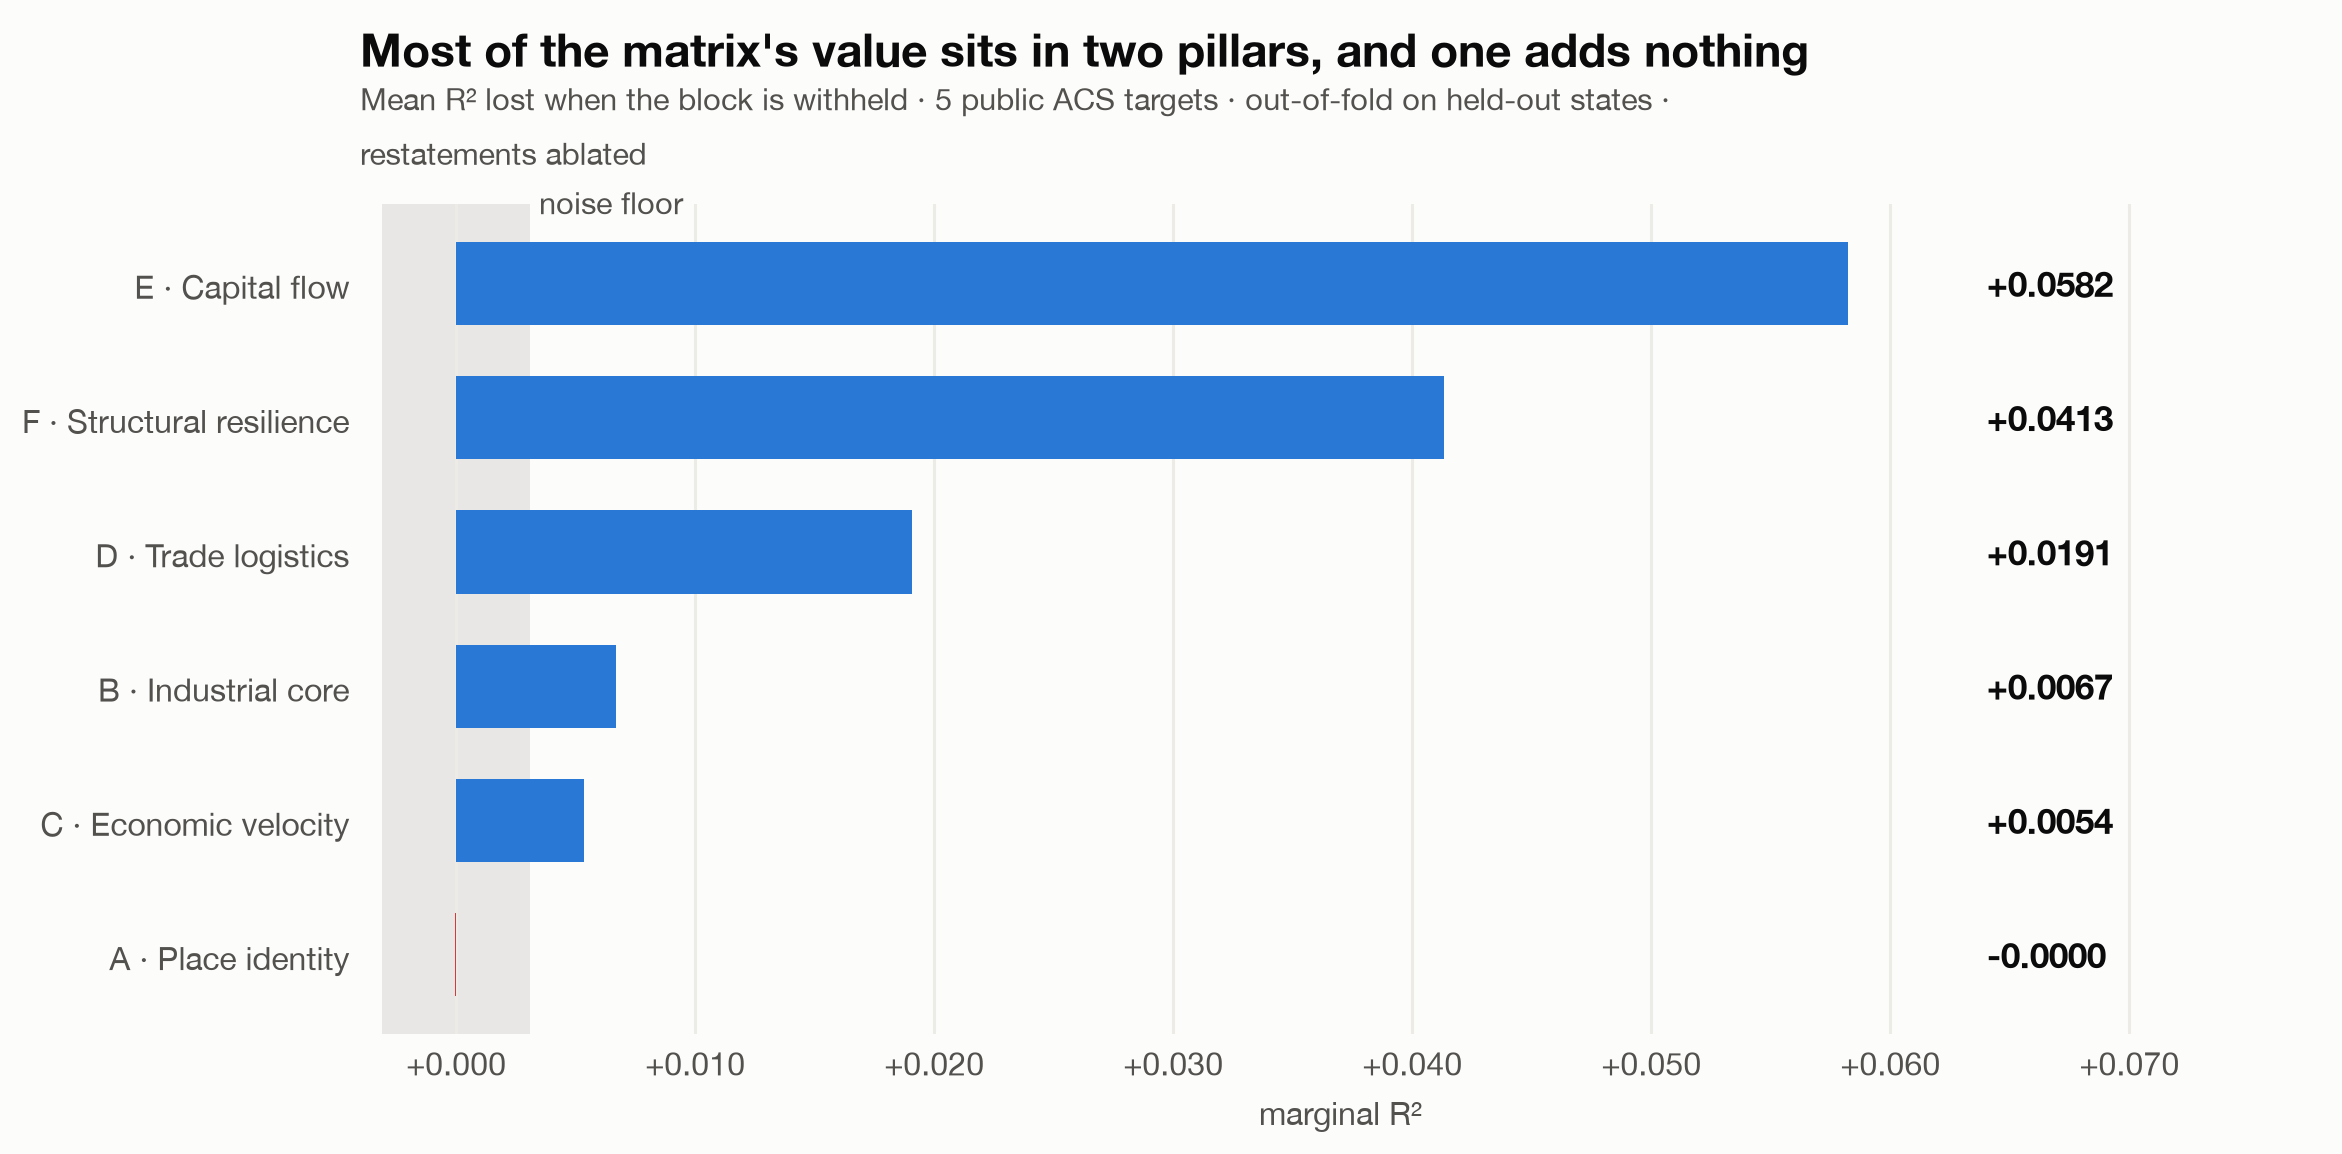

In [7]:
floor = ext["drop_one_noise_floor"]
# Contribution comes from drop_one, NOT from the noise-floor dict: the latter
# carries F's `_no_ametro` robustness variant (+0.0410, scored against a
# different reference model), and quoting it here would silently understate the
# headline figure the findings report and docs both use (+0.0413).
rows = [{"pillar": p,
         "label": PILLAR_NAME[p],
         "contribution": ext["drop_one"][f"size_emacro_drop_{p}"]["mean_contribution_ablated"],
         "floor": floor[p]["max_placebo"],
         "above": floor[p]["n_targets_above_floor"],
         "positive": ext["drop_one"][f"size_emacro_drop_{p}"]["n_positive_ablated"]}
        for p in PILLARS]
worth = pd.DataFrame(rows).sort_values("contribution")

band = float(worth["floor"].max())
hi = float(worth["contribution"].max())
lo = min(-band, float(worth["contribution"].min()))

y = np.arange(len(worth))
fig, ax = plt.subplots(figsize=(11.5, 4.9))
ax.barh(y, worth["contribution"], height=0.62,
        color=[CRITICAL if v <= 0 else BLUE for v in worth["contribution"]])
ax.set_yticks(y)
ax.set_yticklabels(worth["label"])
ax.set_xlim(lo * 1.3, hi * 1.34)

# The noise floor is a property of the measurement, not a series — a shaded band
# rather than a legend entry, so it reads as the bar to clear.
ax.axvspan(-band, band, color=MUTED, alpha=0.5, linewidth=0, zorder=0)
ax.text(band, len(worth) - 0.4, " noise floor", fontsize=10, color=INK2,
        va="center", ha="left")

# Values sit in a fixed right-hand column rather than just past each bar end.
# Tracking the bar end puts Source A's near-zero value on top of its own category
# label and pushes Source E's off the canvas.
for i, v in enumerate(worth["contribution"]):
    ax.text(hi * 1.1, i, f"{v:+.4f}", va="center", ha="left",
            fontsize=11.5, fontweight="bold", color=INK)

ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
ax.set_xlabel("marginal R²", fontsize=10.5, color=INK2)
style(ax,
      "Most of the matrix's value sits in two pillars, and one adds nothing",
      "Mean R² lost when the block is withheld · 5 public ACS targets · "
      "out-of-fold on held-out states · restatements ablated",
      grid_axis="x")
plt.show()

In [8]:
table = worth.sort_values("contribution", ascending=False).copy()
table["Marginal R²"] = table["contribution"].map(lambda v: f"{v:+.4f}")
table["Positive on"] = table["positive"].map(lambda v: f"{v} of 5")
table["Above noise floor on"] = table["above"].map(lambda v: f"{v} of 5")
display(table[["label", "Marginal R²", "Positive on", "Above noise floor on"]]
        .rename(columns={"label": "Pillar"})
        .set_index("Pillar"))

,Marginal R²,Positive on,Above noise floor on
Pillar,,,
E · Capital flow,+0.0582,5 of 5,5 of 5
F · Structural resilience,+0.0413,5 of 5,5 of 5
D · Trade logistics,+0.0191,5 of 5,5 of 5
B · Industrial core,+0.0067,3 of 5,4 of 5
C · Economic velocity,+0.0054,5 of 5,4 of 5
A · Place identity,-0.0000,2 of 5,2 of 5


**The caveat travels with the headline, not after it.** These five targets are
**public proxies, not the consuming team's label** — which is unobtainable under
the scope this project was given. Everything above is an argument by analogy. It is
the strongest non-circular evidence this project can produce, and it is still an
analogy. Appendix A1 takes that objection seriously rather than footnoting it.

**Source F, in one line:** it was the pillar previously flagged as falling short,
it took the fairer test its own status doc had proposed, and it passed decisively —
**+0.0413**, second of the six. Appendix A5 carries the full story, including the
pairwise test it still fails and the seven eighths of its *internal* number that
is USDA restating BLS.

### Source A — the uncomfortable finding

Source A is the pillar this project marked **"Good shape. Done."** Its embedding was
cut on evidence, its 29 typed columns were validated, its schema was frozen first.
It contributes **−0.0000**.

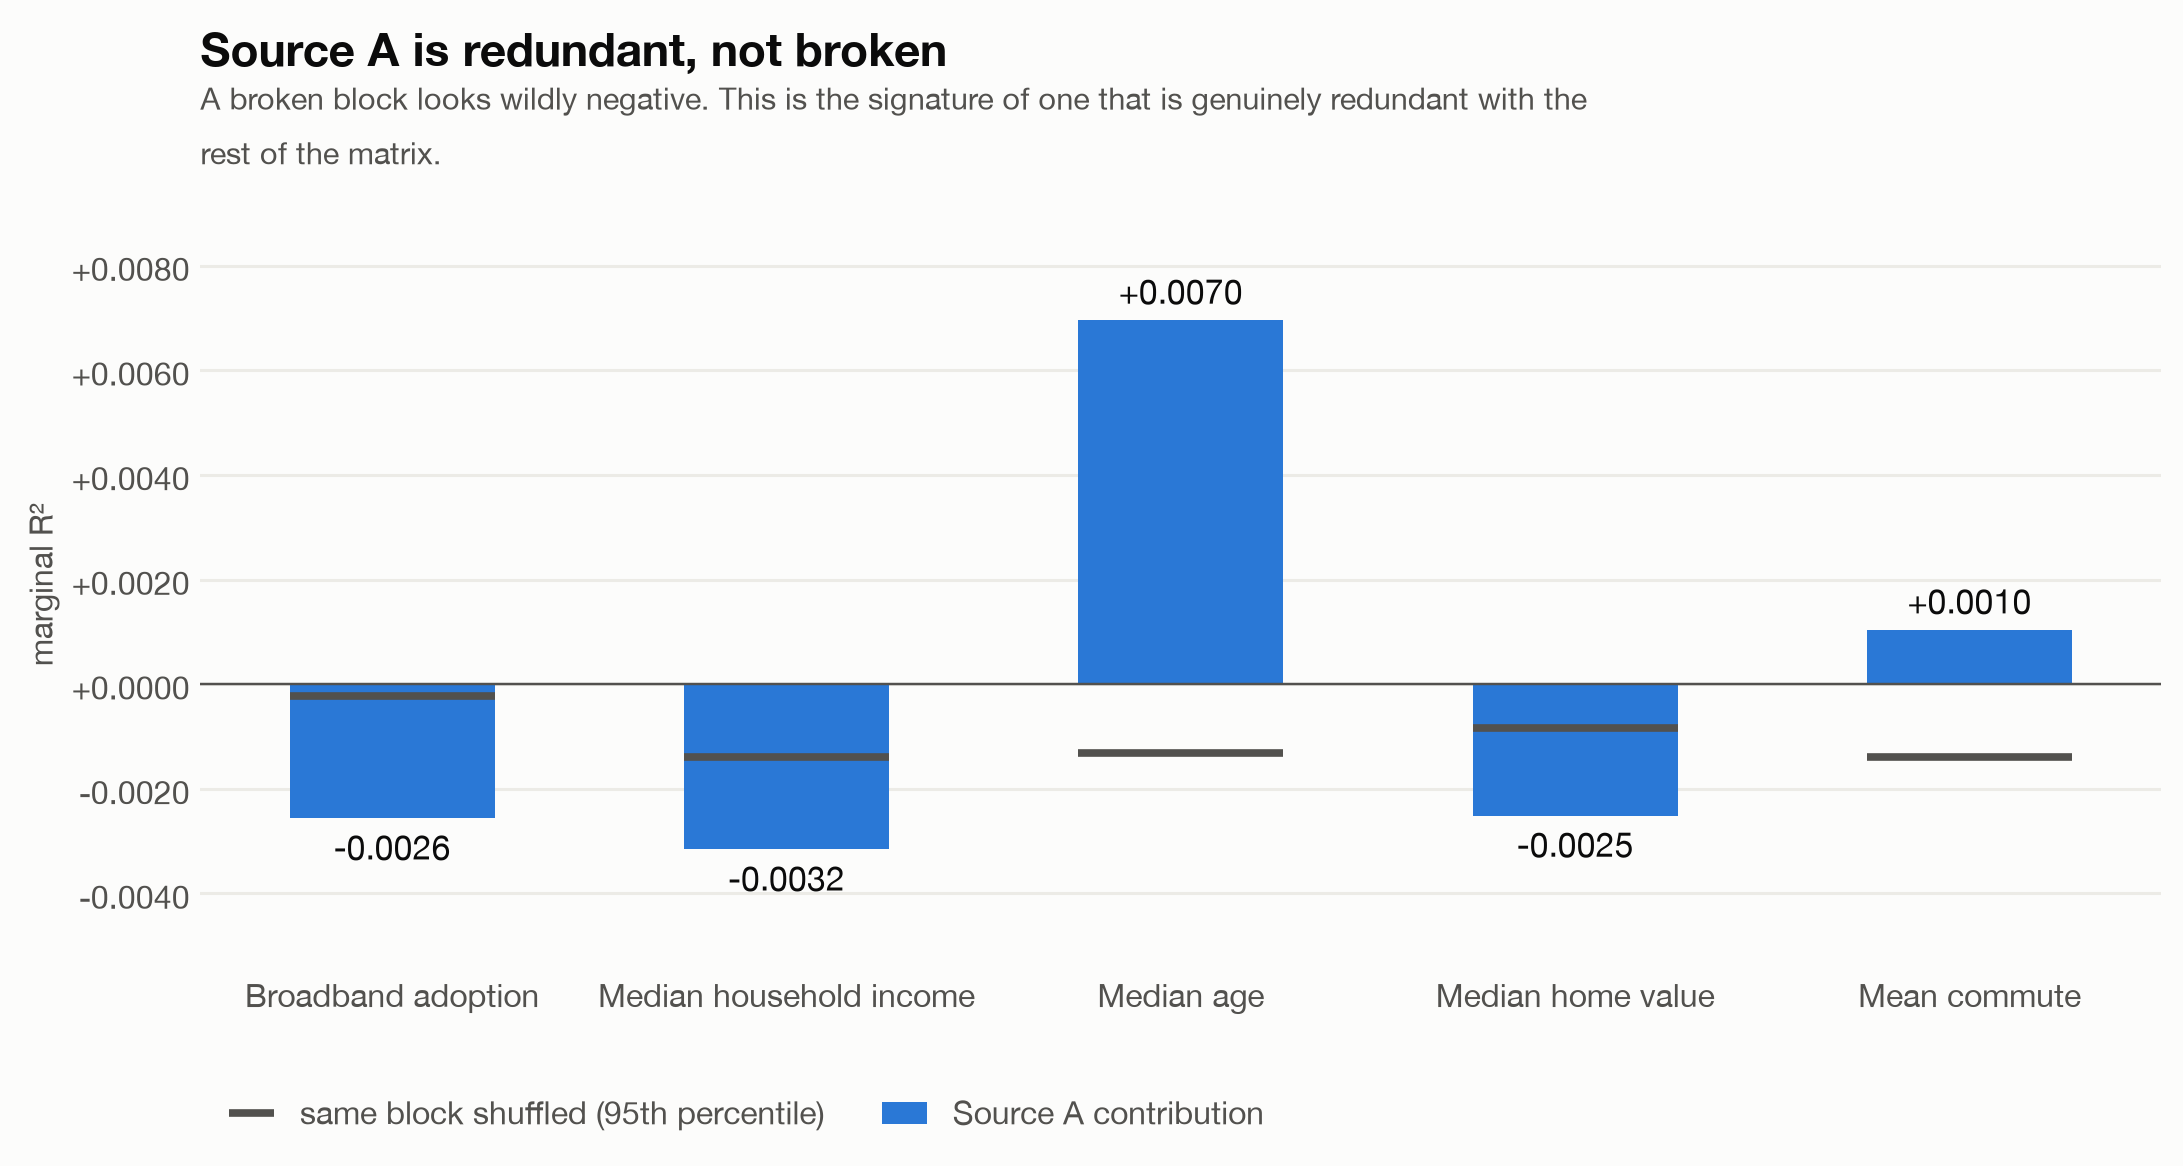

In [9]:
a_stats = ext["drop_one"]["size_emacro_drop_A"]
a_pl = placebo[placebo["pillar"] == "A"].set_index("target")
labels = [TARGET_LABEL[t] for t in TARGET_ORDER]
vals = [a_stats["by_target"][t] for t in TARGET_ORDER]
band = [float(a_pl.loc[t, "placebo_p95"]) if t in a_pl.index else 0.0 for t in TARGET_ORDER]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11.5, 4.5))
# One colour, not red-for-negative: sign is already carried by position against
# the zero line, and a two-colour split would dramatise numbers whose whole point
# is that they are small.
ax.bar(x, vals, 0.52, color=BLUE, label="Source A contribution")
ax.hlines(band, x - 0.26, x + 0.26, color=INK2, linewidth=2.5,
          label="same block shuffled (95th percentile)")
ax.axhline(0, color=INK2, linewidth=0.8, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
span = max(vals + band) - min(vals + band)
ax.set_ylim(min(vals + band) - span * 0.22, max(vals + band) + span * 0.22)
label_bars(ax, x, vals, size=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.4f}"))
ax.set_ylabel("marginal R²", fontsize=10.5, color=INK2)
style(ax,
      "Source A is redundant, not broken",
      "A broken block looks wildly negative. This is the signature of one that is "
      "genuinely redundant with the rest of the matrix.",
      legend=True)
plt.show()

**Not a harness failure.** The same code path produces +0.0582 for E and +0.0413
for F, the placebo distributions behave, and A's per-target numbers are small in
*both* directions rather than wildly negative.

**Not a contradiction of the evidence on file either.** A's typed block was
justified on a marginal lift of **+0.0010** over a baseline holding every other
pillar — a real effect, at p = 0.010 with power 0.92, and a tiny one. A
contribution indistinguishable from zero against five external outcomes is what
that effect size predicts. A is also the only block negative in **both** arms:
−0.0031 internally, −0.0000 externally.

**What it means.** Applied consistently, the operating principle that every pillar
earns its slot on evidence now points at Source A rather than Source F. That is
uncomfortable and it is the honest reading.

**A note on the two Source A results in this notebook, because they are easy to
run together.** Section 2 says A should not branch. This section says A adds
nothing marginal. **They are independent measurements that happen to land on the
same pillar, and the first did not predict the second.** The tier work asked
whether one model or four fits A best, and would have returned exactly the same
answer if A were the strongest pillar in the matrix. Nothing in it anticipated
−0.0000. What is fair to say is narrower and still worth saying: the pillar this
project spent the most instrument time on is the one that turned out to add least.

**And it is not the representation's fault.** The natural defence of A is that
29 regex columns are a thin way to represent an article. That was tested: swapping
in the 384-dimension embedding — which *ties* those columns on standalone lift —
moves A's marginal contribution from −0.0000 to **−0.044**, negative on all five
targets. A richer encoding does not rescue A; it costs more width than it returns
against a matrix that already holds five other pillars.

### The open question this puts to the room

> **Does Source A ship?** The recommendation is to cut it from the shipped
> matrix. Three arguments defend keeping it and two of them have now failed.
>
> *A is nearly free* is an argument about cost, not worth — it justifies leaving
> the code in the repo, not calling A a pillar. *A better representation would
> rescue it* has been tested and does the opposite. *Redundancy is insurance for a
> county missing another pillar* is plausible and remains untested; no
> coverage-failure scenario in this repo has been scored with and without A.
>
> **One argument is still live, and it is the one this project cannot settle.**
> A encodes named industries, universities, ports and protected land. Whether that
> is worth anything depends on whether the downstream target is closer to "who
> lives here" — where A adds nothing — or "what happens here economically." The
> five ACS proxies are squarely the former.
>
> So the evidence points one way and stops short of the decision: **if the
> consuming team's target is demographic, A should come out. If it is economic,
> this test was never the right one.** That is the answer only the commissioning
> side has.

---

## 6. Limits, and where this leaves the project

**1. The fixed-effect objection is unanswered.** Holding out states shows `E_macro`
beats a size baseline on places it has never seen; it does not show it beats a DMA
dummy on places the consumer sees constantly. What the grain question costs in each
direction:

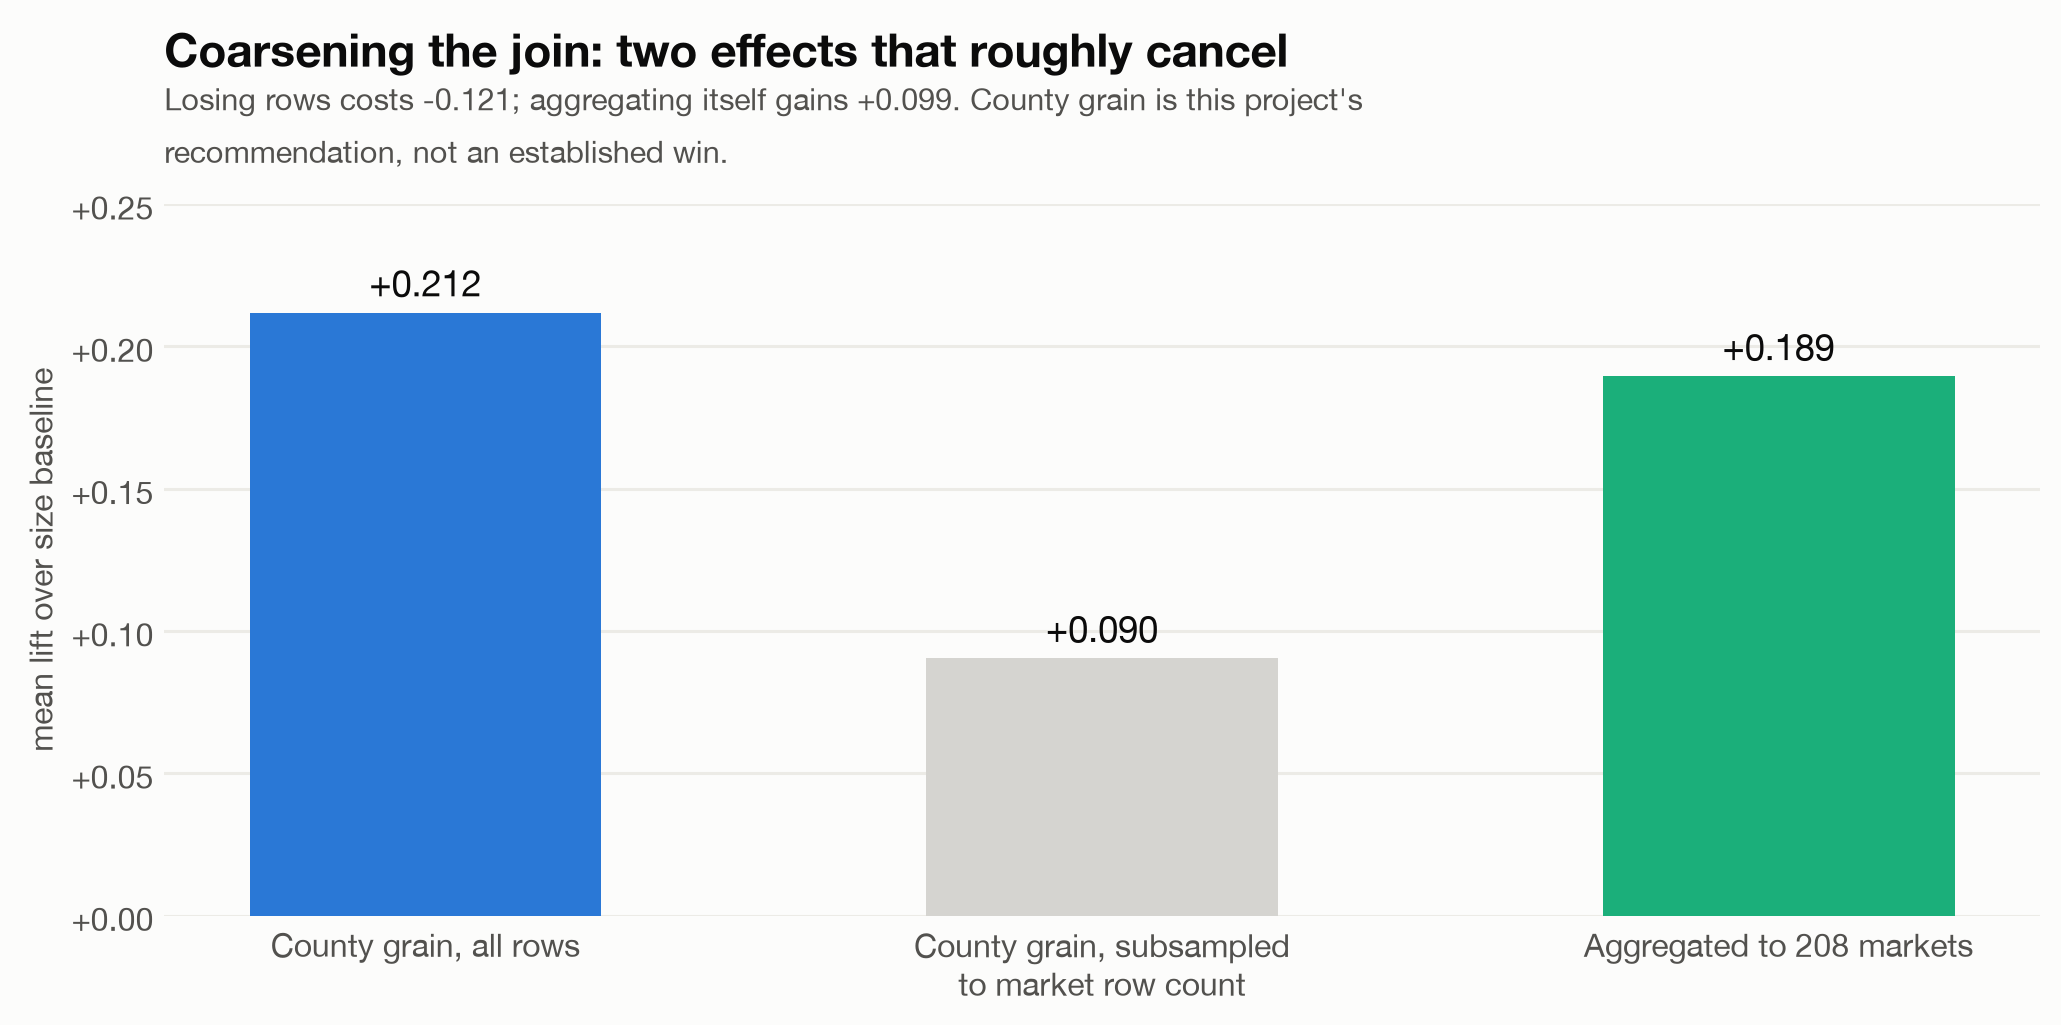

In [10]:
arms = [("County grain, all rows", gst["mean_lift_county_full"], BLUE),
        ("County grain, subsampled to market row count", gst["mean_lift_county_subsample"], MUTED),
        (f"Aggregated to {gst['n_markets']} markets", gst["mean_lift_market_aggregate"], AQUA)]
x = np.arange(len(arms))
vals = [a[1] for a in arms]
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(x, vals, 0.52, color=[a[2] for a in arms])
ax.set_xticks(x)
ax.set_xticklabels([textwrap.fill(a[0], 26) for a in arms])
ax.set_ylim(0, max(vals) * 1.18)
label_bars(ax, x, vals, "{:+.3f}", size=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.set_ylabel("mean lift over size baseline", fontsize=10.5, color=INK2)
style(ax,
      "Coarsening the join: two effects that roughly cancel",
      f"Losing rows costs {gst['row_count_effect']:+.3f}; aggregating itself gains "
      f"{gst['aggregation_effect']:+.3f}. County grain is this project's "
      "recommendation, not an established win.")
plt.show()

**2. On the smallest counties the model cannot win — and that is a data fact, not a
model failure.** The size-only baseline scores a *negative* R² there. ACS publishes
a margin of error with every estimate, and ingesting those alongside the values
splits each outcome's variance into signal and sampling noise. In the smallest
population decile, **30% of the variance is sampling noise** — error no model can
ever explain. In the largest, under 1%.

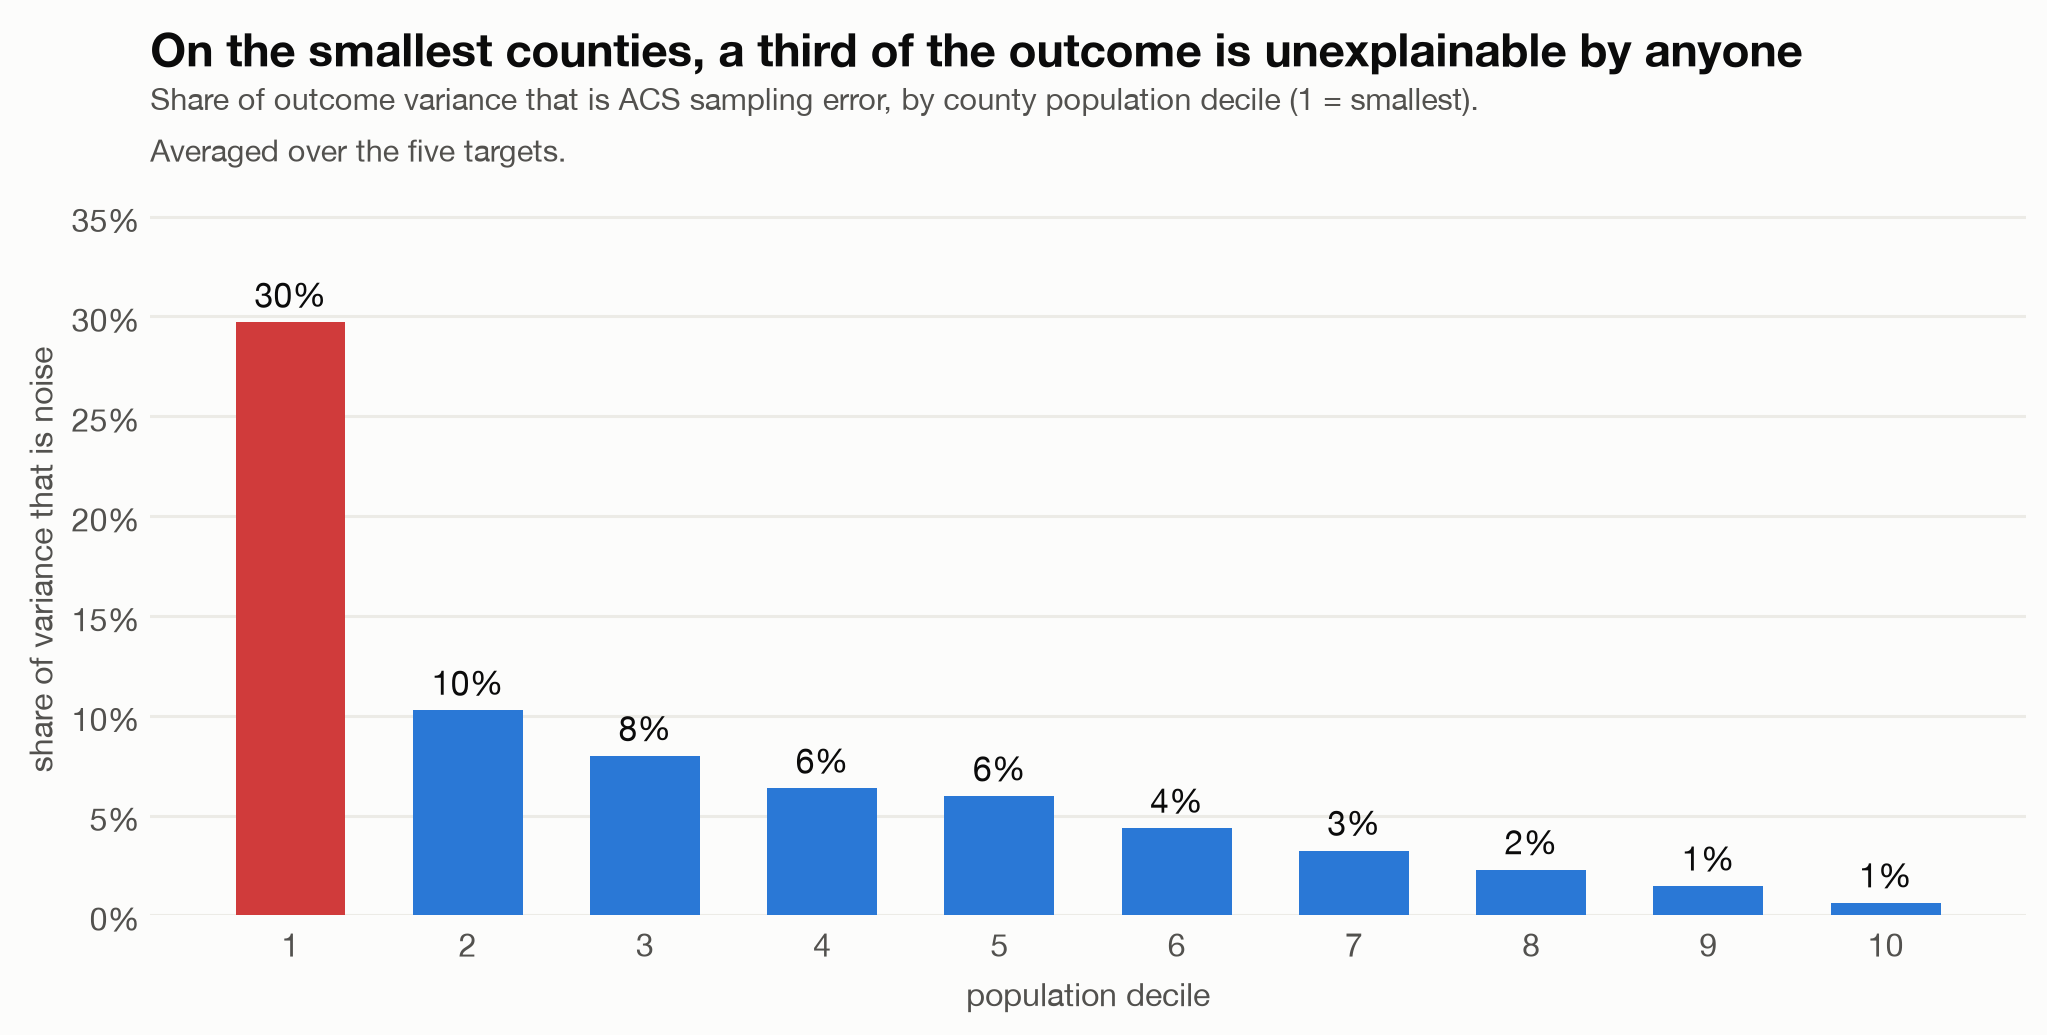

In [11]:
d = (decile.groupby("population_decile")
     .agg(noise_share=("noise_share", "mean"),
          median_population=("median_population", "median"))
     .reset_index())
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(d["population_decile"], d["noise_share"], 0.62,
       color=[CRITICAL if v > 0.15 else BLUE for v in d["noise_share"]])
ax.set_xticks(d["population_decile"])
ax.set_ylim(0, float(d["noise_share"].max()) * 1.2)
label_bars(ax, d["population_decile"], d["noise_share"], "{:.0%}", size=11)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("population decile", fontsize=10.5, color=INK2)
ax.set_ylabel("share of variance that is noise", fontsize=10.5, color=INK2)
style(ax,
      "On the smallest counties, a third of the outcome is unexplainable by anyone",
      "Share of outcome variance that is ACS sampling error, by county population "
      "decile (1 = smallest). Averaged over the five targets.")
plt.show()

**3. Three more, in a line each.** No **downstream label**, and none possible under
this scope. Everything here is **cross-sectional** — temporal transfer, the one
thing a fixed effect genuinely fails at, is untested. And the **sibling tiers do
not line up**: `E_local` is at H3 res-8, `E_census` does not exist, and nobody owns
the reconciliation.

### Where this leaves the project

In [12]:
readiness = pd.DataFrame([
    ("Six sources ingested, validated, schema frozen", "Done",
     "3,143–3,144 counties; six schema docs; vintage per pillar"),
    ("Evidence against a target outside the six pillars", "Done",
     f"{ext['mean_lift_over_size_ablated']:+.3f} mean R² over a size baseline, 5 of 5 positive"),
    ("Each pillar's worth measured, not asserted", "Done",
     "drop-one, restatements ablated, noise floor measured"),
    ("Evidence against the consumer's real target", "Not possible in scope",
     "no downstream label; public proxies only"),
    ("Answer to the DMA fixed-effect objection", "Open",
     "needs the join grain settled"),
    ("Temporal transfer tested", "Not started",
     "cross-sectional only; the strongest untested argument"),
    ("Fusion / serving format", "Deferred by design",
     "packaging, not evidence; grain must settle first"),
], columns=["What a go/no-go needs", "Status", "Where it stands"])
display(readiness.set_index("What a go/no-go needs"))

,Status,Where it stands
What a go/no-go needs,,
"Six sources ingested, validated, schema frozen",Done,"3,143–3,144 counties; six schema docs; vintage..."
Evidence against a target outside the six pillars,Done,"+0.190 mean R² over a size baseline, 5 of 5 po..."
"Each pillar's worth measured, not asserted",Done,"drop-one, restatements ablated, noise floor me..."
Evidence against the consumer's real target,Not possible in scope,no downstream label; public proxies only
Answer to the DMA fixed-effect objection,Open,needs the join grain settled
Temporal transfer tested,Not started,cross-sectional only; the strongest untested a...
Fusion / serving format,Deferred by design,"packaging, not evidence; grain must settle first"


**The remaining path**, in order, measured in weeks of availability:

1. **Settle the join grain** — the single highest-leverage unblock; nothing after it
   is safe to build first.
2. **Benchmark against a geographic fixed effect** — the test that decides whether
   `E_macro` earns a slot in a production model.
3. **Test temporal transfer** — the one argument a fixed effect cannot answer.
4. **Then package** — schema freeze, imputation policy, serving format. Days, not
   weeks: `build_matrix()` already joins all six pillars.

**Not blocked by any of it:** ingestion, validation, schema freeze and the external
benchmark are complete and stand on their own.

---

# Appendix

Written to be read without a narrator.

## A1 — Do public proxies mean anything?

The strongest objection available against section 2, and it deserves a straight
answer rather than a footnote.

**The objection.** `E_macro` is scored against ACS broadband adoption, median
household income, median age, median home value and mean commute. The consuming
team predicts none of those. A feature layer that explains median age tells you
nothing about whether it explains revenue per ad request.

**Conceded immediately.** The objection is correct on its own terms. No result here
is a direct test of usefulness to the consuming team, and none is presented as one.
The label that would make such a test possible is unobtainable: the project was
scoped to public and open-source data only, deliberately and from the start.

**Why the proxies are still worth what they cost.** The alternative was not a better
test — it was the pillar-versus-pillar sweep, which is *circular*. It can establish
that Source B and Source E see the same economy and cannot establish that either
predicts anything at all. Moving to an external target replaces a circular
measurement with a non-circular one. That is a real gain in evidential status even
though the target is a proxy.

**What the proxies license.** That the six pillars carry information counties'
*size* does not already carry — the baseline is population and density and the lift
is measured on held-out states, so it is not memorisation. That the pillars are not
interchangeable, since the drop-one design holds the other five constant. And that
the ordering among them is not arbitrary — E and F clear the noise floor on 5 of 5
targets by an order of magnitude, A does not.

**What they do not license.** Any claim about **magnitude** against an ad-tech
target; +0.190 on ACS outcomes forecasts nothing. Any claim that the **ordering
transfers** — Source A could rank higher against an economically-flavoured target,
which is precisely the section 3 argument for not cutting it unilaterally. And any
answer to the **fixed-effect objection**, which is a different question.

**What would settle it.** One pass of the same drop-one design against a real
downstream target, at the grain the consuming team actually joins on. That needs
either a label or a collaborator inside that team, and is the single most valuable
thing that could be added to this project.

## A2 — Tier method detail

**Source A tier edges**, on lead-section character count: stub <100, thin 100–283,
mid 284–461, rich ≥462 — quartile-ish cuts on the observed distribution, not round
numbers chosen in advance.

**Source E tier edges**, on `num_returns`: T1 <2,200, T2 2,200–11,700, T3
11,700–100,000, T4 ≥100,000. Five tax years, TY2018–TY2022.

**What each branching arm actually consumed.** The flat arm fits one coefficient per
feature across all counties. The crossed arm fits 29 features × 4 tiers = 120
columns against targets whose smallest sample is n ≈ 1,026. The separate arm fits
four independent models, each on roughly a quarter of the rows, with no shared
penalty across them.

**Why the crossed arm loses even though it is strictly more expressive.** Ordinary
bias–variance: the ridge penalty large enough to control 120 columns also
over-shrinks the coefficients that matter. Expressiveness the data cannot pay for
is a cost, not a capability.

**A p-value worth stating rather than burying.** On a paired rank test the crossed
variant reads p = 0.040 against the flat block's p = 0.115. That does not reverse
the section: the flat block still carries the higher mean lift (+0.00307 against
+0.00279), which is the quantity the shipping decision uses. It does mean the flat
block's advantage is a point estimate rather than a demonstrated gap.

**The other Source A arms tested in the same round**, all of which lost to the
shipped design:

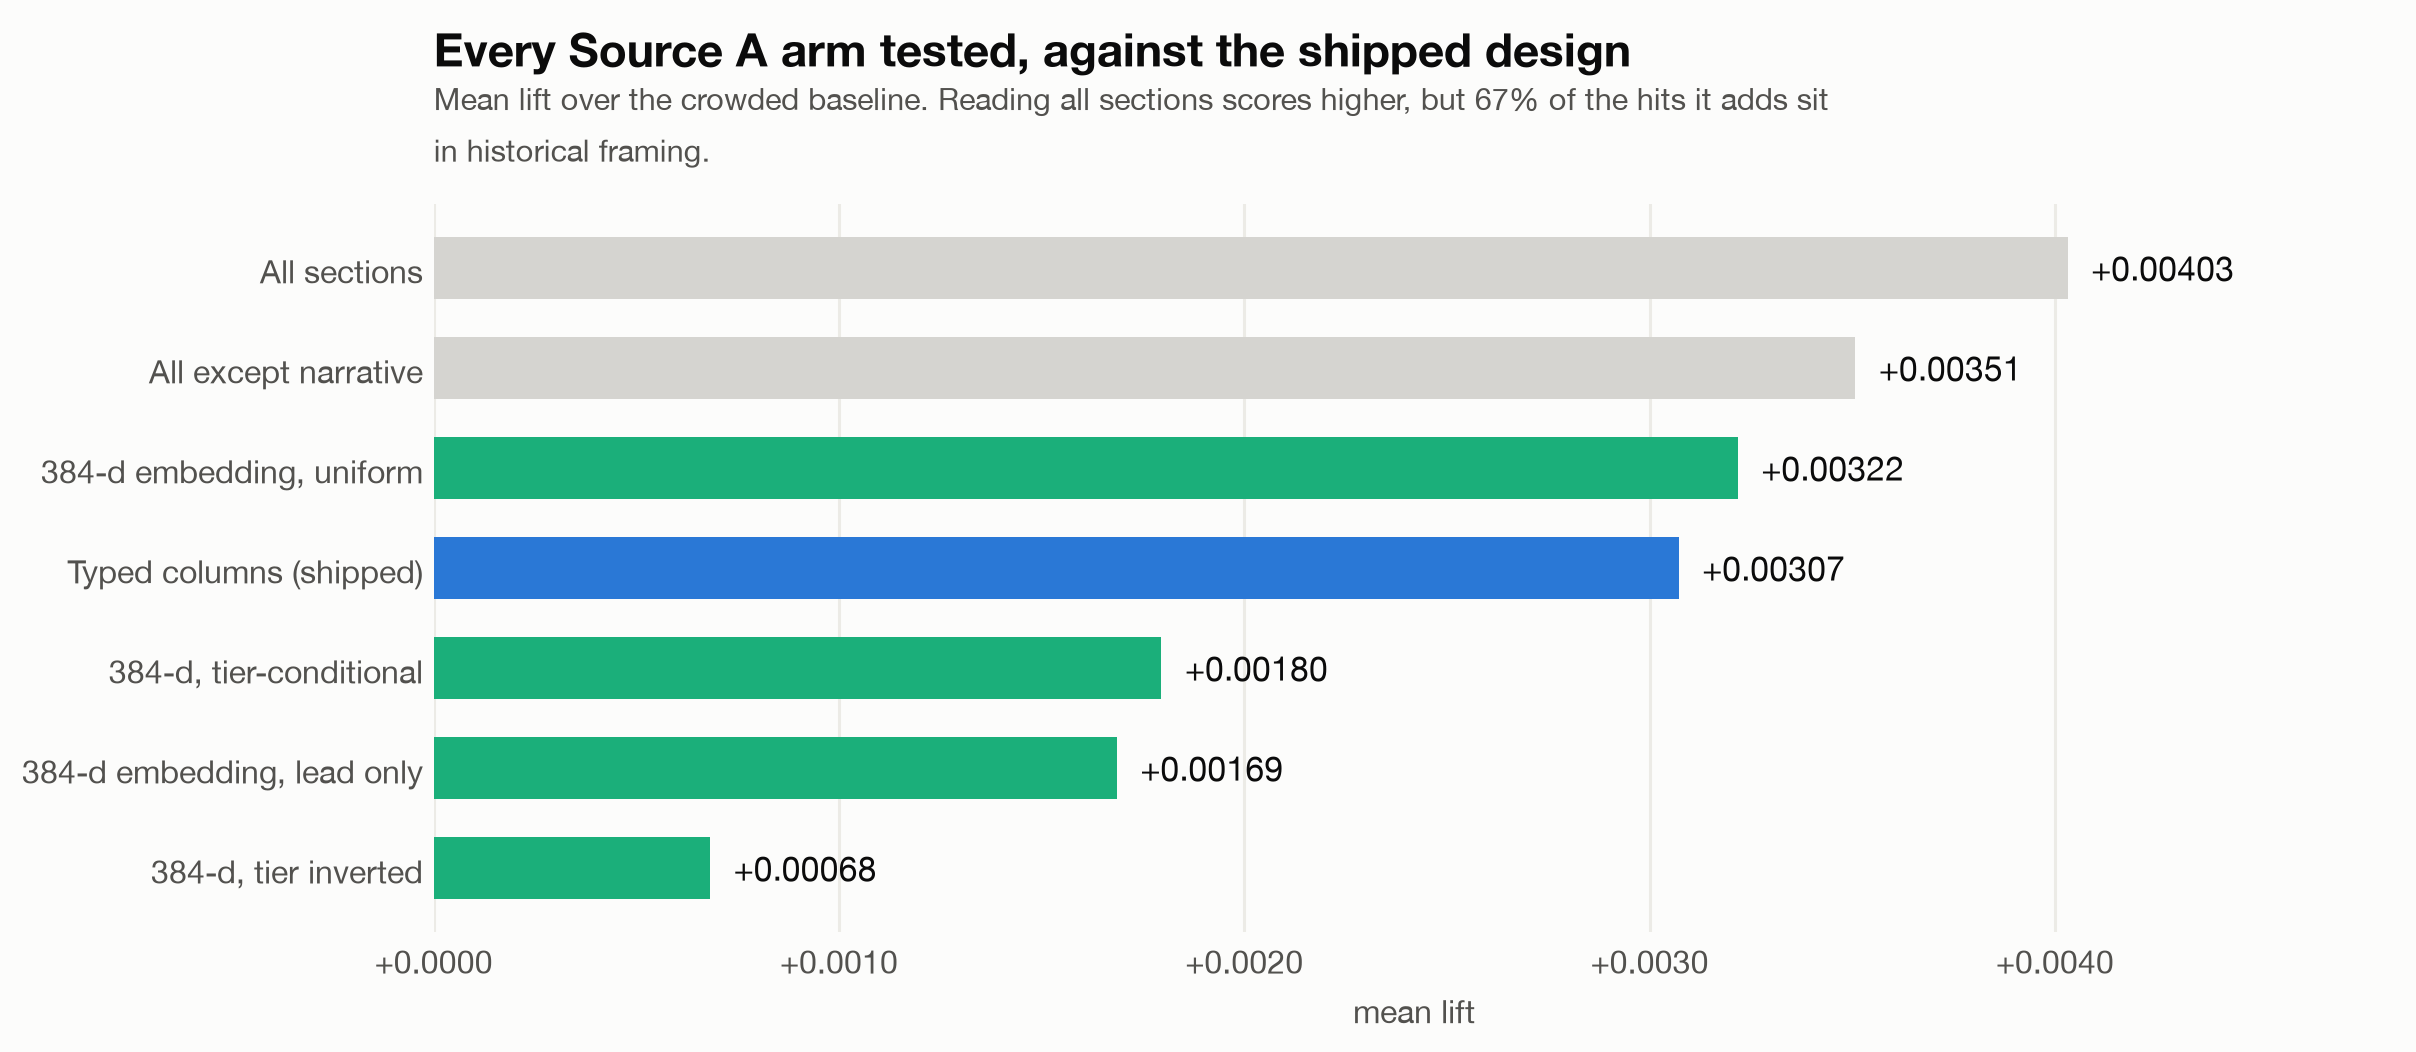

In [13]:
arms = [
    ("Typed columns (shipped)", scope["scopes"]["economy"]["mean_lift"], BLUE),
    ("All sections", scope["scopes"]["all_sections"]["mean_lift"], MUTED),
    ("All except narrative", scope["scopes"]["no_narrative"]["mean_lift"], MUTED),
    ("384-d embedding, lead only", embed["representations"]["lead_only"]["mean_lift"], AQUA),
    ("384-d embedding, uniform", embed["representations"]["uniform"]["mean_lift"], AQUA),
    ("384-d, tier-conditional", embed["representations"]["tier_conditional"]["mean_lift"], AQUA),
    ("384-d, tier inverted", embed["representations"]["tier_conditional_inverse"]["mean_lift"], AQUA),
]
arms = sorted(arms, key=lambda a: a[1])
y = np.arange(len(arms))
vals = [a[1] for a in arms]
fig, ax = plt.subplots(figsize=(11.5, 4.3))
ax.barh(y, vals, height=0.62, color=[a[2] for a in arms])
ax.set_yticks(y)
ax.set_yticklabels([a[0] for a in arms])
ax.set_xlim(0, max(vals) * 1.2)
label_bars(ax, y, vals, "{:+.5f}", size=11, horizontal=True)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.4f}"))
ax.set_xlabel("mean lift", fontsize=10.5, color=INK2)
style(ax,
      "Every Source A arm tested, against the shipped design",
      "Mean lift over the crowded baseline. Reading all sections scores higher, but "
      "67% of the hits it adds sit in historical framing.",
      grid_axis="x")
plt.show()

Reading **all** sections scores higher than the shipped economy-only rule
(+0.00403 against +0.00307) and was still not shipped: 67% of the hits it adds sit
in historical framing, which makes it a defunct-industry detector wearing a
current-economy label. That is a precision judgement, not a scoring one, and it is
the one place in this project where a higher number was deliberately declined.
**The per-tier breakdown of the embedding arms is in section 2**, including the
drop-one sweep that locates which tier the tier-conditional rule actually costs.

**A correction worth recording, made 2026-08-17.** The MiniLM arms above were
first run with a chunk cap that truncated input at ~9,000 characters, which bound
on **1,871 of 3,144 counties (59.5%)** and discarded 43% of the uniform arm's own
text. On that truncated input the encoder appeared to lose to the typed block.
Raised to ~57,600 characters, where it binds on 47 counties, the uniform arm rises
from +0.00226 to **+0.00322** and its row-normalised twin to **+0.00351** — level
with the typed block rather than behind it. The conclusion that the *input* should
not branch on tier is unaffected and is cleaner uncapped. Full detail in
`source-a-findings.md` §20.

## A3 — Drop-one method

**The pre-registered rule**, verbatim from the implementation plan, written before
either script was run and not renegotiated afterwards:

> F ships as a pillar if its marginal contribution — R²(size + all pillars) −
> R²(size + all pillars except F), pooled out-of-fold over the five external ACS
> targets, with restatement columns ablated — is positive on a majority of targets
> and above the shuffled-feature noise floor. Otherwise `E_macro` ships five
> pillars and the go/no-go deck says so plainly.

**Design.** For each pillar, fit two models: one holding county size plus all six
pillars, one holding county size plus five. The difference in out-of-fold R² is that
pillar's marginal contribution. Repeated for all six and for the B+E pair.

**Estimator.** Ridge regression on an imputed design matrix. Missing values are
imputed rather than dropped, because the null patterns are themselves informative
(BLS suppresses ~35% of the LQ matrix) and listwise deletion would silently change
the county population under test.

**Folds.** `GroupKFold` on `state_fips` — spatially blocked, so a model never
predicts a county in a state it trained on. Stricter than random k-fold, and the
right strictness: county features are spatially autocorrelated, and random folds
would let a neighbouring county leak the answer.

**Restatement ablation.** Where a column in one pillar restates a column in another
(Source A's `has_metro_attachment` against Source F's `metro_2023`; Source F's
industry flags against Source B's location quotients), it is removed from both the
full and the reduced model. A pillar that only restated a neighbour then scores zero
by construction, which is the intended behaviour.

**Noise floor.** Each block is shuffled and re-scored — 49 reps in the internal arm,
20 per pillar × target in the external arm. The largest contribution any shuffled
block produced anywhere is +0.0031, and that is the bar drawn in section 2.

**Two arms.** The internal arm scores against 29 in-matrix targets and measures
coherence. The external arm scores against the five ACS targets and is the one the
verdicts rest on. Where they disagree the external arm wins — being unpredictable
from the other five pillars is also exactly what an independent information source
looks like.

## A4 — Limitations, carried over unchanged

- **The targets are public proxies, not the consumer's label**, which is
  structurally unobtainable. Every conclusion is by analogy.
- **20 placebo reps per pillar × target, 49 in the internal arm.** Enough to place a
  floor near zero against contributions an order of magnitude larger. **Not enough
  to resolve a borderline contribution — B's and C's ordering (+0.0067, +0.0054)
  should not be quoted as settled.**
- **Contribution is not importance under a different model class.** Everything here
  is ridge on an imputed design. A gradient-boosted consumer might distribute credit
  differently; only the internal arm carries a GBM cross-check.
- **Cross-sectional and single-period.** Temporal transfer is untested.
- **This does not answer the fixed-effect objection.** It reallocates credit among
  pillars, given that the matrix as a whole beats a size baseline on held-out states.

## A5 — Source F, in full

F is the pillar a previous status doc flagged as falling short, and the reason was
real. Its one strong relationship in the whole 15-pair sweep was against Source D
freight tonnage, **r = 0.495 raw — the largest raw effect anywhere in that sweep —
collapsing to r = −0.057 once county size is controlled.** The apparent link was
population riding along in both variables.

The resolution then on file was to keep F and reclassify it as a "structural
anchor," justified by what county typology definitionally *is* rather than by
measured performance. That was a rationalisation, and it was withdrawn.

**What replaced it.** The status doc named the fairer test itself — does F explain
residual variance once B/C/D/E are already in the model — and that test was run. F
contributes **+0.0413**, second of the six, positive on 5 of 5 targets and above the
noise floor on 5 of 5, where the largest contribution any shuffled block produced
anywhere was +0.0031.

**Both facts travel together.** F still fails the pairwise hub test. It passed the
residual-variance test that was pre-registered for it. The first instrument was the
wrong one for a categorical structural variable, and that was said before the
numbers existed, not after.

**The caution that belongs beside the headline:**

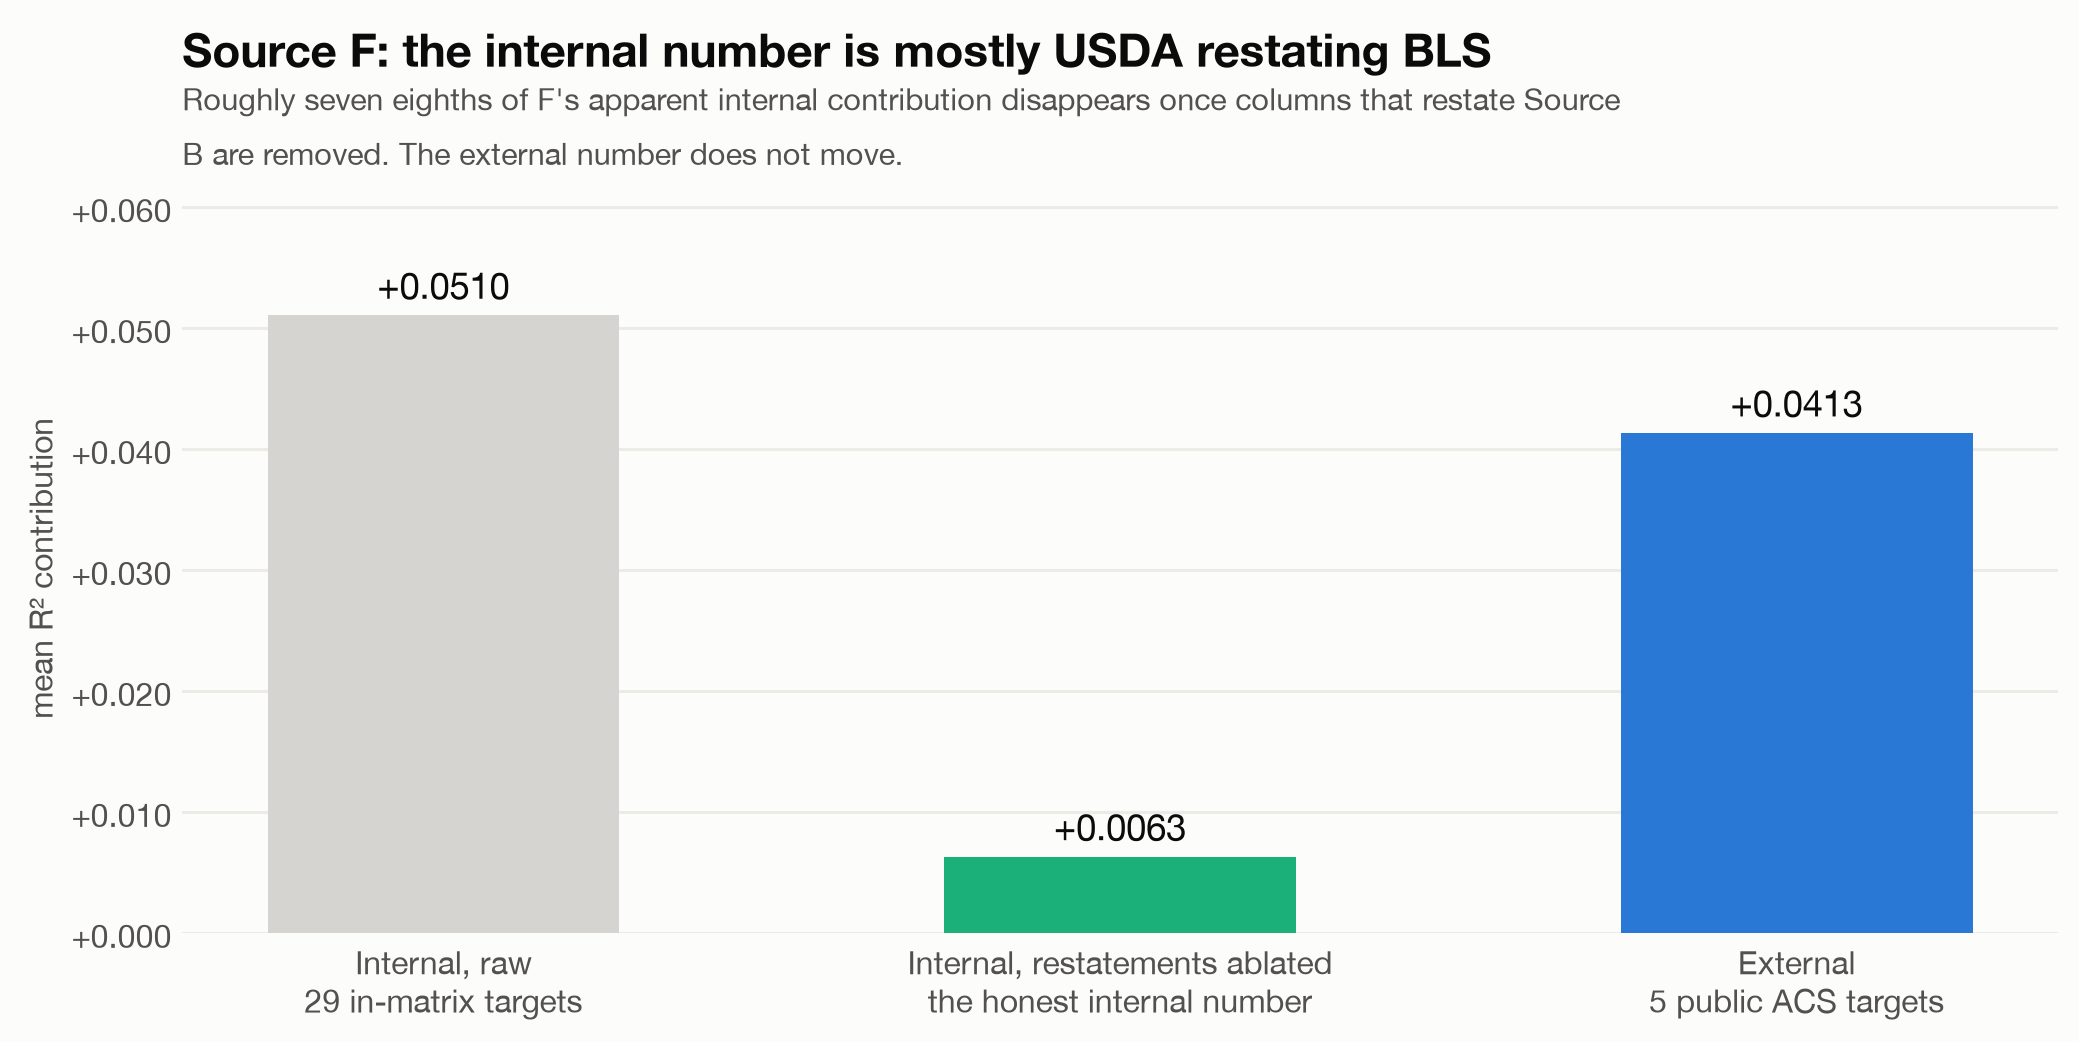

In [14]:
fb = blk["by_block"]["F"]
# Headline external figure, not the `_no_ametro` robustness variant — see the
# comment on the section 5 pillar-worth figure.
f_ext = ext["drop_one"]["size_emacro_drop_F"]["mean_contribution_ablated"]
# NOTE: newlines in these labels are escaped because this cell's source is a
# non-raw triple-quoted string in the builder — an unescaped \n would be
# consumed at build time and split the string literal.
bars = [
    ("Internal, raw\n29 in-matrix targets", fb["mean_lift"], MUTED),
    ("Internal, restatements ablated\nthe honest internal number",
     fb["mean_lift_ablated"], AQUA),
    ("External\n5 public ACS targets", f_ext, BLUE),
]
x = np.arange(len(bars))
vals = [b[1] for b in bars]
fig, ax = plt.subplots(figsize=(11, 4.3))
ax.bar(x, vals, 0.52, color=[b[2] for b in bars])
ax.set_xticks(x)
ax.set_xticklabels([b[0] for b in bars])
ax.set_ylim(0, max(vals) * 1.18)
label_bars(ax, x, vals, size=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
ax.set_ylabel("mean R² contribution", fontsize=10.5, color=INK2)
style(ax,
      "Source F: the internal number is mostly USDA restating BLS",
      "Roughly seven eighths of F's apparent internal contribution disappears once "
      "columns that restate Source B are removed. The external number does not move.")
plt.show()

**Seven eighths of F's apparent internal contribution is USDA restating industry
composition BLS already measures.** That redundancy is real inside the six-pillar
system and does not bind against outcomes outside it — the same ablation moves F's
external figure by 0.0003, which is why the external arm is the one the verdict
rests on.

## A6 — Pillar vintages

In [15]:
v = vintages.copy()
v["Pillar"] = v["pillar"].map(PILLAR_NAME)
v = v.rename(columns={"as_of_date": "As of", "reference_period": "Reference period",
                      "cadence": "Update cadence"})
display(v[["Pillar", "As of", "Reference period", "Update cadence"]].set_index("Pillar"))

,As of,Reference period,Update cadence
Pillar,,,
A · Place identity,2026-08-03,scrape date (no reference period),continuous
B · Industrial core,2025-12-31,2025 Q4,quarterly
C · Economic velocity,2025-12-31,"unemployment through 2025, real GDP through 2024",monthly (unemployment) / annual (GDP)
D · Trade logistics,2022-12-31,2022,every ~5 years
E · Capital flow,2022-12-31,tax year 2022 (cross-year columns span TY2018-...,annual
F · Structural resilience,2025-12-31,2025 edition (2023 OMB metro delineation),every ~10 years


## A7 — For the consuming team, when it comes to that

**The warning that matters more than which columns ship.** An impression-level
training table joined to `E_macro` carries only 3,143 distinct feature values, so
the effective sample size is the county count — not the row count. Random k-fold
will make this feature layer look good in evaluation and do nothing in production.
**Cluster standard errors by `fips_code`; use grouped, spatially blocked folds.**

Two shorter notes. **Nulls are explicit**: BLS suppresses ~35% of the Source B LQ
matrix, those cells stay null with a `disclosure_*` flag, and IRS publishes no
suppression flag at all — a model must be able to tell "missing" from "zero."
**Size columns are held out deliberately** in `SIZE_COLUMNS`, so a pillar can be
re-derived at a coarser geography; they are not features.

## A8 — Artifact index

Every figure above is computed from a committed artifact. Nothing is hardcoded.

| Section | Reads | Produced by |
|---|---|---|
| 2 · the discount | `external_target_stats.json` (`by_target`) | `scripts/analyze_external_target.py` |
| 2 · pillar worth | `external_target_stats.json` (`drop_one`, `drop_one_noise_floor`) | `scripts/analyze_external_target.py` |
| 3 · Source F | `pillar_block_marginal_stats.json` (`by_block`) | `scripts/analyze_pillar_block_marginal.py` |
| 3 · Source A | `external_target_drop_one_placebo.csv` | `scripts/analyze_external_target.py` |
| 4 · grain | `grain_effect_stats.json` | `scripts/analyze_grain_effect.py` |
| 4 · sampling noise | `outputs/external_target_by_decile.csv` | `scripts/analyze_external_target.py` |
| 5 · ruled out | `source_a_section_scope_stats.json`, `source_a_tiered_embedding_stats.json` | `scripts/analyze_source_a_section_scope.py`, `scripts/analyze_source_a_tiered_embedding.py` |
| A4 · Source E tiers | `source_e_tier_stats.json` | `scripts/analyze_source_e_tiers.py` |
| A5 · vintages | `outputs/pillar_vintages.csv` | `scripts/pillar_vintage.py` |

Long-form evidence:
`analysis-output/cross-source/pillar-marginal-findings.md`,
`analysis-output/cross-source/external-target-findings.md`,
`analysis-output/E_macro_key_findings.ipynb`,
`docs/pillar_status.md`, `docs/PROJECT_GOAL.md`.